# Model Evaluation
---
- Display some images with predictions to confirm things are working as they should.
- Display some images as they appeared to the model during training, to confirm the image augmentation was sensible.
- Calculates performance metrics on randomly selected test image crops held aside from the training datasets (with all classes)
- Repeat the calculations from test sets, using the whole images in-place as it would be used in real-life.  Images taken from new locations (cameras not used for training data), using the inference script.  This dataset has been somewhat balanced to avoid the reported result being skewed by a particular class.
- Logs various performance metrics to the monitoring csv file, located at:  `Project/Python/Setup/Performance_Monitor.csv`

In [2]:
import torch
import numpy as np
import shutil
import random
import ast
from pathlib import Path, PureWindowsPath
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import plotly.express as px
import warnings
from IPython.display import display, Image
import os
import time
from torchvision import transforms
import torch.nn.functional as F
import gc
import json
import yaml
import pandas as pd
import sys
import sklearn.metrics as skm
from sklearn.metrics import confusion_matrix
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import recall_score, precision_score
import seaborn as sns
from datetime import datetime
import Inference
import cv2
from Inference import get_model
from Training import get_dataloaders, encode_df, ImageAugmentation
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

from Inference import find_dataframe
from Prioritise_Data import remove_duplicates_by_hash, limit_randomly
import h5py
from shutil import copy2
from joblib import Parallel, delayed

In [3]:
NUM_WORKERS = 4 if sys.platform == 'linux' else 0

For the re-running this notebook over a previous training run a temporary path can be set to a settings file.

In [ ]:
#TEMP_SETTINGS_PATH = '/home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Exp_46_Run_21.yaml'
#TEMP_SETTINGS_PATH = r'C:\Users\User\OneDrive - Department of Conservation\Desktop\Alita\Settings\Exp_43_Run_01.yaml'
TEMP_SETTINGS_PATH = None
VERBOSE = False if TEMP_SETTINGS_PATH is None else True
EMPTY_DETECT_THRESHOLD=0.2
EMPTY_CLASSIFY_THRESHOLD = 0.2 #BA: 0.881 with this @ 0.1, #0.881 @ 0.2, 0.880 @ 0.3,  0.872 @ 0.4
#CLASSIFY_CONF_THRESHOLD = 0.4 #Unused here, for individual presence/absence predictions

In [5]:
class Colour:
    S = '\033[1m' + '\033[94m'
    E = '\033[0m'


class Paths:
    DATA_FOLDER_NM = 'Data'
    EXPS_FOLDER_NM = 'Experiments'
    INPUT_FOLDER_NM = 'Inputs'
    CROP_LABELS_NM = 'crop_labels.parquet'
    RUNS_FOLDER_NM = 'Runs'
    SETTINGS_FOLDER_NM = 'Settings'
    RESULTS_FOLDER_NM = 'Results'  # Increment or name this to name the results folder
    MODELS_FOLDER_NM = 'Models'
    WEIGHTS_FOLDER_SUFFIX = '_weights'
    IMAGE_FOLDER_NM = 'Cropped_Images'
    DEFAULT_IMAGE_FOLDER_NM = 'Independent_Images'
    TEST_FOLDER_NM = 'Test_Images'
    #DEFAULT_IMAGE_FOLDER_NM = 'Independent_Images_Small'
    DEBUG_IMAGE_FOLDER_NM = 'Debugging_Inference'
    EMPTY_IMAGE_FOLDER_NM = 'Empty_Images'
    VAL_SPLIT_PARQUET_NM = '_val_split.parquet'
    TRAINING_METRICS_NM = '_monitor_train.png'
    WEIGHTS_FN_SUFFIX = '_best_weights.pt'
    RESULTS_DF_SUFFIX = '_df.pkl'
    CLASS_NAMES = '_class_names.json'
    CLASS_ACCURACY_OUT = '_accuracy_by_class.csv'
    CF_MATRIX_SUFFIX_OUT = '_confusion_matrix.csv'
    CF_MATRIX_NORM_SUFFIX_OUT = '_confusion_matrix_norm.csv'
    CF_MATRIX_FIG_SUFFIX_OUT = '_confusion_matrix.png'
    PREDS_PARQUET_SUFFIX_OUT = '_infer_predictions.parquet'
    BAL_IND_PREDICTIONS = '_balanced_preds.csv'
    SETUP_FOLDER_NM = 'Setup'
    PERFORMANCE_LOG = 'Performance_Monitor.csv'

    def __init__(self, experiment_name, run_id):
        _project_dir = Path(os.path.abspath('')).parent
        _experiment_dir = _project_dir / self.DATA_FOLDER_NM / self.EXPS_FOLDER_NM / experiment_name
        _results_dir = _experiment_dir / self.RUNS_FOLDER_NM / run_id / self.RESULTS_FOLDER_NM 
        
        self.models_dir = _experiment_dir / self.RUNS_FOLDER_NM / run_id / self.MODELS_FOLDER_NM
        self.val_parquet_path = _results_dir / f'{run_id}{self.VAL_SPLIT_PARQUET_NM}'
        self.balanced_preds_path = _results_dir /  f'{run_id}{self.BAL_IND_PREDICTIONS}'
        self.weights_pth = self.models_dir / f'{run_id}{self.WEIGHTS_FOLDER_SUFFIX}' / f'{run_id}{self.WEIGHTS_FN_SUFFIX}'
        self.labels_pth = _experiment_dir / self.INPUT_FOLDER_NM / self.CROP_LABELS_NM
        self.image_dir = _experiment_dir / self.INPUT_FOLDER_NM / self.IMAGE_FOLDER_NM
        self.independent_image_dir = _project_dir / self.DATA_FOLDER_NM / self.DEFAULT_IMAGE_FOLDER_NM
        self.test_image_dir = _project_dir / self.DATA_FOLDER_NM / self.TEST_FOLDER_NM
        self.debug_image_dir = _project_dir / self.DATA_FOLDER_NM / self.DEBUG_IMAGE_FOLDER_NM
        self.empty_image_dir = _project_dir / self.DATA_FOLDER_NM / self.EMPTY_IMAGE_FOLDER_NM
        self.train_metrics_pth = _results_dir / f'{run_id}{self.TRAINING_METRICS_NM}'
        self.class_names_pth = _results_dir / f'{run_id}{self.CLASS_NAMES}'
        self.pickle_paths = {'val_target_df': _results_dir / f'{run_id}_val_target{self.RESULTS_DF_SUFFIX}',
                        'val_pred_df': _results_dir / f'{run_id}_val_pred{self.RESULTS_DF_SUFFIX}',
                        'train_target_df': _results_dir / f'{run_id}_train_target{self.RESULTS_DF_SUFFIX}',
                        'train_pred_df': _results_dir / f'{run_id}_train_pred{self.RESULTS_DF_SUFFIX}'}
        self.cf_matrix_pth = _results_dir / f'{run_id}{self.CF_MATRIX_SUFFIX_OUT}'
        self.cf_matrix_norm_pth = _results_dir / f'{run_id}{self.CF_MATRIX_NORM_SUFFIX_OUT}'
        self.cf_matrix_fig_pth = _results_dir / f'{run_id}{self.CF_MATRIX_FIG_SUFFIX_OUT}'
        self.class_acc_pth = _results_dir / f'{run_id}{self.CLASS_ACCURACY_OUT}'
        self.performance_log_pth = Path(os.path.abspath('')) / self.SETUP_FOLDER_NM / self.PERFORMANCE_LOG

        print(f'The project folder is located at {_project_dir}')
        print(f'The results folder is located at {_results_dir}')
        print(f'The val_split is located at {self.val_parquet_path}')
        print(f'The model weights are located at {self.weights_pth}')
        print(f'The model performance metrics will be logged to {self.performance_log_pth}')
        print(f'The test images from unused locations will be located in {self.independent_image_dir}')
        print(f'The empty test images will be located in {self.empty_image_dir}')


class TrainConfig:
    def __init__(self):
        self.EXPERIMENT_NAME = 'Exp_26'
        self.RUN_ID = 'Run_02'
        self.DESCRIPTION = 'Evaluating Some Experiment'
        self.MODEL_NAME = 'tf_efficientnetv2_l.in21k_ft_in1k'
        self.HEAD_NAME = 'ClassifierHead' # Alternative: BasicHead
        self.INDEPENDENT_TEST_ONLY = ['N01', 'BWS', 'EBF', 'EM1', 'ES1'] + ['EL1', 'ES1', 'N02', 'N04', 'N06', 'N08', 'OTR', 'WRO']
        self.CLASSES_TO_EXCLUDE=  ['shag', 'moth', 'skink', 'lizard', 'fernberd', 'skylark', 'grey_duck', 'long_tailed_cuckoo']
        self.CLASSES_TO_IGNORE = [] #still train with images and detect, but assign to 'unknown' eg [penguin], A penguin and kea walk into a bar, the detector only pays attention to the kea, since the penguin is 'unknown'
        self.CLASS_JOINS =  {'lizard':['skink', 'lizard'], 'finch':['greenfinch', 'goldfinnch', 'chaffinch'], 'quail':['quail_california', 'quail_brown']} 
        self.CLASS_NAME_CHANGE = {'penguin':'little_blue_penguin', 'song thrush':'thrush', 'NZ_falcon':'nz_falcon'} # Folders labelled the first thing are re-labeled the second thing
        self.DEBUG = False  #Remember to change back to false after debugging!
        self.EXIF_DT_FORMATS = ['%Y:%m:%d %H:%M:%S', '%y:%m:%d %H:%M:%S', '%d/%m/%Y %H:%M:%S']


class InferConfig:
    BATCH_SIZE = 64
    EMPTY_THRESHOLD = .2 # If the classifier score is below this the image will automatically be classified as 'empty'
    MD_EMPTY_THRESHOLD =  0.4 #If the md score is below this the image will automatically be classed as 'empty'
    TO_MONITOR = ['cat', 'mouse', 'possum', 'rat', 'stoat']


class ImageConfig:
    '''Wrapper class for image processing parameters'''
    CROP_SIZE = 600
    BUFFER = 0
    RESCALE = True
    REMOVE_BACKGROUND = False
    EDGE_FADE = False
    RESIZE_METHOD = 'md_crop'
    MIN_FADE_MARGIN = 0.05
    MAX_FADE_MARGIN = 0.05
    MIN_FADE_MARGIN = 0
    MAX_FADE_MARGIN = 0
    IMAGE_SIZE = 480 #Final width and height in pixels for the cropped images
    INPUT_MEAN = [ 0.485, 0.456, 0.406 ] # mean to be used for normalisation, using values from ImageNet.
    INPUT_STD = [ 0.229, 0.224, 0.225 ] # stddev to be used for normalisation, using values from ImageNet.


def get_settings_path():
    '''Access a temporary .json file created to pass the settings file path from a master python script to a notebook, then delete
    intended only to access a specific file once from the master script'''
    script_dir = Path(os.path.abspath(''))
    json_pth = script_dir / 'temp_settings_path.json'
    try:
        with open(json_pth, 'r') as json_file:
            json_data = json.load(json_file)
            settings_path = Path(json_data['settings_path'])
            if not settings_path:
                print('No settings path was found in "temp_settings_path.json"')
                sys.exit()
    except:  #if running stand-alone
        if TEMP_SETTINGS_PATH:
            settings_path = Path(TEMP_SETTINGS_PATH)
    if json_pth.exists():
        print(f'Deleting the json file from {json_pth}')
        json_pth.unlink()
    return settings_path


def get_settings(settings_pth=None):
    """Gets an instance of the configuration classes, then looks for the settings file, 
    if it finds a matching key the value is updated, or evaluated to python expressions then updated"""

    evaluate_list = ['CLASSES', 'CLASSES_TO_EXCLUDE', 'CLASSES_TO_IGNORE', 'CLASS_JOINS',
                     'CLASS_NAME_CHANGE', 'LOCATIONS_TO_EXCLUDE','INDEPENDENT_TEST_ONLY',           #'INDEPENDENT_TEST_ONLY'
                     'EDGE_FADE', 'EXIF_DT_FORMATS', 'REMOVE_BACKGROUND', 'RESIZE_METHOD']

    train_settings = TrainConfig()
    infer_settings = InferConfig()
    image_settings = ImageConfig()

    if settings_pth:
        with open(settings_pth, 'r') as yaml_file:
            yaml_data = yaml.load(yaml_file, Loader=yaml.FullLoader)
        for key, value in yaml_data.items():
            for cfg in [train_settings, image_settings, infer_settings]:
                if hasattr(cfg, key):
                    if (key in evaluate_list) and (isinstance(value, str)):
                        setattr(cfg, key, ast.literal_eval(value))
                    else:
                        setattr(cfg, key, value)

    return train_settings, infer_settings, image_settings

def get_settings(settings_pth=None):
    """Gets an instance of the configuration classes, then looks for the settings file, 
    if it finds a matching key, the value is updated, or evaluated as a Python expression then updated.
    """

    evaluate_list = {
        'CLASSES', 'CLASSES_TO_EXCLUDE', 'CLASSES_TO_IGNORE', 'CLASS_JOINS',
        'CLASS_NAME_CHANGE', 'LOCATIONS_TO_EXCLUDE','INDEPENDENT_TEST_ONLY',
        'EDGE_FADE', 'EXIF_DT_FORMATS', 'REMOVE_BACKGROUND', 'RESIZE_METHOD'
    }

    train_settings = TrainConfig()
    infer_settings = InferConfig()
    image_settings = ImageConfig()

    if settings_pth:
        with open(settings_pth, 'r') as yaml_file:
            yaml_data = yaml.safe_load(yaml_file)  # Use safe_load to prevent security risks

        for key, value in yaml_data.items():
            for cfg in (train_settings, image_settings, infer_settings):
                if hasattr(cfg, key):  # Check if attribute exists
                    if key in evaluate_list and isinstance(value, str):
                        try:
                            setattr(cfg, key, ast.literal_eval(value))  # Evaluate safely
                        except (SyntaxError, ValueError):
                            print(f"Warning: Could not evaluate key '{key}' from YAML.")
                    else:
                        setattr(cfg, key, value)  # Assign value directly

    return train_settings, infer_settings, image_settings


def get_settings(settings_pth=None):
    """Gets an instance of the configuration classes, then looks for the settings file, 
    if it finds a matching key the value is updated, or evaluated to python expressions then updated"""

    evaluate_list = {
        'CLASSES', 'CLASSES_TO_EXCLUDE', 'CLASSES_TO_IGNORE', 'CLASS_JOINS',
        'CLASS_NAME_CHANGE', 'LOCATIONS_TO_EXCLUDE','INDEPENDENT_TEST_ONLY',
        'EDGE_FADE', 'EXIF_DT_FORMATS', 'REMOVE_BACKGROUND', 'RESIZE_METHOD'
    }

    train_settings = TrainConfig()
    infer_settings = InferConfig()
    image_settings = ImageConfig()

    if settings_pth:
        with open(settings_pth, 'r') as yaml_file:
            yaml_data = yaml.safe_load(yaml_file)  # Use safe_load to prevent security risks

        for key, value in yaml_data.items():
            for cfg in (train_settings, image_settings, infer_settings):
                if hasattr(cfg, key):  # Check if attribute exists
                    if key in evaluate_list and isinstance(value, str):
                        try:
                            value = eval(value)  # Evaluate safely
                        except (SyntaxError, ValueError):
                            print(f"Warning: Could not evaluate key '{key}' from YAML.")
                    else:
                        setattr(cfg, key, value)  # Assign value directly

    print(Colour.S + 
          'Training with settings from settings file: '
          + f'{train_settings.EXPERIMENT_NAME}, run: {train_settings.RUN_ID}'
          + Colour.E)

    return train_settings, infer_settings, image_settings

### Helper Functions

In [6]:
def test_cuda():
    gpu = torch.cuda.is_available()
    device = torch.device("cuda" if gpu else "cpu")
    print('Using torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if gpu else 'CPU'))
    if gpu:
        gc.collect()
        torch.cuda.empty_cache()
    return device, gpu


def plot_class_distribution(df):
    total_counts = df['Species'].value_counts().reset_index()
    total_counts.columns = ['Species', 'total_count']
    fig = px.bar(total_counts, x=total_counts.Species, log_y=True, y=total_counts.total_count, template='seaborn',
    hover_data=['Species', 'total_count'], color='Species', height=400)
    fig.update_layout(title=f'Total count for each target class')
    fig.update_layout(showlegend=False)
    fig.update_xaxes(categoryorder='total descending')
    fig.show()


def remove_rare_classes(target_df, pred_df, rare_threshold):
    col_sums = target_df.sum(axis=0)
    original_width = target_df.shape[1]
    mask = col_sums >= rare_threshold

    remove_list=[]
    total_removed = 0
    for column_name, col_sum in col_sums.items():
        if col_sum < rare_threshold:
            remove_list.append((column_name,col_sum))
            total_removed +=col_sum
    
    remove_cols = original_width - mask.sum()
    target_df = target_df.loc[:, mask]
    pred_df = pred_df.loc[:, mask]  

    rows_to_remove = target_df.index[target_df.sum(axis=1) == 0]
    target_df = target_df.drop(rows_to_remove)
    pred_df = pred_df.drop(rows_to_remove)

    rows_with_targets = target_df.any(axis=1)
    target_df = target_df[rows_with_targets]
    pred_df = pred_df[rows_with_targets]

    if remove_cols > 0:
        print(f'From counting loop: Removing {len(remove_list)} species, {total_removed} instances: {remove_list}, ')
        print(f'Removing {remove_cols} classes as they have less than {rare_threshold} samples')
        print(f'Also removing {len(rows_to_remove)} image instances, as they were from those classes')
    return target_df, pred_df


def get_map_score(target_df, pred_df, average='macro'):
    target_df, pred_df = remove_rare_classes(target_df, pred_df, 1)
    col_sums = target_df.sum()
    mask = col_sums >= 1 #keeping this in to avoid division by 0
    targs_arr = target_df.loc[:,mask].copy().values
    preds_arr = pred_df.loc[:,mask].copy().values
    if average is None:
        scores_vals = average_precision_score(targs_arr,preds_arr, average=None)
        if isinstance(scores_vals, float): #handle the situation where only one species is present
            scores_vals = [scores_vals]  
        scores_keys = target_df.columns[mask].tolist()
        scores_dict = {k:v for (k,v) in zip(scores_keys, scores_vals)}
    else:
        scores_dict = {'mean': average_precision_score(targs_arr,preds_arr, average=average)}   
    return scores_dict


def get_ba_score(targets_df, predictions_df):
    targets_df, predictions_df = remove_rare_classes(targets_df, predictions_df, 1)
    target_arr = np.argmax(targets_df.values, axis=1)
    preds_arr = np.argmax(predictions_df.values, axis=1)
    return balanced_accuracy_score(target_arr, preds_arr)


def get_accuracy_score(targets_df, preds_df, normalize=True):
    targets_df, preds_df = remove_rare_classes(targets_df, preds_df, 1)
    target_arr = np.argmax(targets_df.values, axis=1)
    preds_arr = np.argmax(preds_df.values, axis=1)
    return skm.accuracy_score(target_arr,  preds_arr, normalize=normalize, sample_weight=None)


def get_f1_score(targets_df, predictions_df):
    targets_df, predictions_df = remove_rare_classes(targets_df, predictions_df, 1)
    target_arr = np.argmax(targets_df.values, axis=1)
    preds_arr = np.argmax(predictions_df.values, axis=1)
    return skm.f1_score(target_arr, preds_arr, pos_label=1, average='macro', zero_division=np.nan)


def get_prr(targets_df, predictions_df):
    targets_df, predictions_df = remove_rare_classes(targets_df, predictions_df, 1)
    target_arr = np.argmax(targets_df.values, axis=1)
    preds_arr = np.argmax(predictions_df.values, axis=1)
    return skm.f1_score(target_arr, preds_arr, pos_label=1, average='binary', zero_division=np.nan)


def plot_map_by_class(df_target, df_pred, min_samples=5, height=1200):
    '''Needs a prediction and target df with only matching columns containing scores'''
    df_target, df_pred = remove_rare_classes(df_target, df_pred, min_samples)
    map_dict = get_map_score(df_target, df_pred, average=None)
    col_sums = df_target.sum()
    sorted_cols = col_sums.sort_values(ascending=False)
    names = [name for name in sorted_cols.index]
    counts = [count for count in sorted_cols]
    scores = [map_dict[name] for name in names]
    df = pd.DataFrame({'names': names, 'counts': counts, 'scores': scores})
    df["scores"] = pd.to_numeric(df["scores"])
    df["counts"] = pd.to_numeric(df["counts"])
    fig = px.bar(df, x='scores', y='names', color='counts', orientation='h', hover_data=['counts', 'scores'], range_x=[0, 1])
    fig.update_layout(height=height, title='Average Precision Score by Species')
    fig.show()
    return names, scores


def balance_data(df, parent_dir, num_class_place, class_total):
    def random_select(group, max_to_keep):
        n_rows = min(max_to_keep, len(group))
        return group.sample(n=n_rows)
    stem = str(parent_dir)
    df = df.copy()
    df['Place'] = [str(Path(x).relative_to(stem).parts[0]) if stem in x else '' for x in df.index]
    df['Place_Target'] = df['Place'] + '-' + df['Targets']
    df['File_Path'] = df.index
    df = df.groupby('Place_Target', group_keys=False).apply(random_select, num_class_place)
    df = df.groupby('Targets', group_keys=False).apply(random_select, class_total)
    df.reset_index(drop=True, inplace=True)
    keep_paths = df['File_Path'].to_list()
    return keep_paths


def data_from_json(data_pth):
    with open(data_pth, 'r') as f:
        data = json.load(f)
    return data


class ImageDisplayer:
    '''A helper class to take normalised tensors and display with Numpy in orinal colour'''
    def __init__(self, mean, std):
        self.inv_mean = [-m/s for m, s in zip(mean, std)]
        self.inv_std = [1/s for s in std]
        self.inv_normalise = transforms.Normalize(self.inv_mean, self.inv_std)

    def show_image(self, image):
        '''Convert un-normalise and convert from Tensor image to numpy for display'''
        image = self.inv_normalise(image)
        plt.imshow(np.transpose(image, (1, 2, 0)))  


def load_image(image_path, mode):
    try:
        image = cv2.imread(image_path)
        if image is not None:
            if mode == 'RGB':
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            return image
        else:
            print(f"Warning: Unable to load the image at '{image_path}'. Skipping...")
            return None
    except Exception as e:
        print(f"Warning: Unable to load the image at '{image_path}'. Error: {str(e)}. Skipping...")
    return None

class BatchViewer:
    def __init__(self, loader, lookup_dict, displayer, batch_size=32, min_display=8, max_display=32):
        """
        Initializes the BatchViewer with a DataLoader and maintains the iterator state.

        Args:
            loader (torch.utils.data.DataLoader): The DataLoader object.
            lookup_dict (dict): Dictionary mapping label indices to class names.
            displayer (function): Function to visualize an image.
            batch_size (int, optional): Batch size. Defaults to 32.
            min_display (int, optional): Minimum images to display. Defaults to 8.
            max_display (int, optional): Maximum images to display. Defaults to 32.
        """
        self.loader = loader
        self.lookup_dict = lookup_dict
        self.displayer = displayer
        self.batch_size = batch_size
        self.min_display = min_display
        self.max_display = max_display
        self.batch_iter = iter(loader)

    def show_batch(self):
        """
        Loads and displays the next batch of images. Resets automatically if the end is reached.
        """
        try:
            images, labels, _ = next(self.batch_iter)
        except StopIteration:
            print("End of dataset reached. Restarting from the beginning.")
            self.batch_iter = iter(self.loader)
            images, labels, _ = next(self.batch_iter)

        num_ims = max(self.min_display, min(len(images), self.batch_size, self.max_display))
        num_cols = 4
        num_rows = (num_ims + num_cols - 1) // num_cols

        fig = plt.figure(figsize=(12, int(num_ims * 0.75)))

        for idx in range(num_ims):
            ax = fig.add_subplot(num_rows, num_cols, idx + 1, xticks=[], yticks=[])
            self.displayer(images[idx])
            label_tensor = labels[idx].numpy()
            max_arg_idx = np.argmax(label_tensor)
            ax.set_title(self.lookup_dict[max_arg_idx])

        return images


def show_predictions(t_tensor,
                     p_tensor,
                     images,
                     lookup_dict,
                     displayer,
                     min_display=8,
                     max_display=32,
                     batch_size=32):
    num_ims = max(min_display, min(len(images), batch_size, max_display))
    num_cols = 4
    num_rows = int(np.ceil(num_ims/num_cols))
    fig = plt.figure(figsize=(12, int(num_ims*0.75)))
    target_vals = torch.argmax(t_tensor, dim=1)
    predict_vals = torch.argmax(p_tensor, dim=1)
    for idx in np.arange(num_ims):
        ax = fig.add_subplot(num_rows, num_cols,  idx+1, xticks=[], yticks=[])
        t_class = lookup_dict[target_vals[idx].item()]
        p_class = lookup_dict[predict_vals[idx].item()]
        displayer(images[idx])
        if t_class == p_class:
            title = f'{p_class}'  #{target_vals[idx].item()}
            ax.title.set_color('green')
        else:
            title = f'{p_class} ({t_class})'# {predict_vals[idx].item()}    {target_vals[idx].item()}
            ax.title.set_color('red')
        ax.set_title(title)
    return


class BatchPredictor:
    def __init__(self, loader, model, device, activation='Sigmoid'):
        """
        Initializes the BatchPredictor.

        Args:
            loader (torch.utils.data.DataLoader): The DataLoader object.
            model (torch.nn.Module): The PyTorch model for inference.
            device (torch.device): The device ('cuda' or 'cpu') to run inference on.
        """
        self.loader = loader
        self.model = model.to(device)  # Ensure model is on the correct device
        self.device = device
        self.batch_iter = iter(loader)  # Store iterator state
        self.activation=activation

    def predict_batch(self):
        """
        Runs inference on the next batch. Resets automatically if the end is reached.

        Returns:
            cpu_targets (torch.Tensor): Ground truth labels (on CPU).
            cpu_probs (torch.Tensor): Model prediction probabilities (on CPU).
            cpu_images (torch.Tensor): Batch images (on CPU).
        """
        try:
            images, targets, _ = next(self.batch_iter)  # Get next batch
        except StopIteration:
            print("End of dataset reached. Restarting from the beginning.")
            self.batch_iter = iter(self.loader)  # Reset iterator
            images, targets, _ = next(self.batch_iter)
            

        images = images.to(self.device)

        with torch.no_grad():
            logits = self.model(images)
            if self.activation == 'Sigmoid':
                probs = F.sigmoid(logits)
            else:
                probs = F.softmax(logits, dim=1)

        # Move tensors to CPU and detach
        return (
            targets,
            probs.cpu().detach(),
            images.cpu().detach(),
        )


def show_inferred_imgs(in_df, num_ims=9, rescale=True, crop_size=480, buffer=0): 
    
    def pad_to_square(image):
        height, width, channels = image.shape
        size=max(height, width)
        dtype = image.dtype
        square_image = np.zeros((size, size, channels), dtype=dtype)
        y_offset = (size - height) // 2
        x_offset = (size - width) // 2
        square_image[y_offset:y_offset+height, x_offset:x_offset+width] = image
        return square_image, x_offset, y_offset

    def get_new_scale(row, width, height, crop_size, buffer):
        """figures out how much to scale down the new image to, so the max(bounding-box) + buffer = the desired crop size
        only effects images where the crop box would be greater than the crop size"""
        clamp = lambda n: max(min(1, n), 0)
        x_min = clamp(row['x_min'] - buffer)
        y_min = clamp(row['y_min'] - buffer)
        x_max = clamp(row['x_min'] + row['Width'] + buffer)
        y_max = clamp(row['y_min'] + row['Height'] + buffer)
        max_dimension = max([(x_max - x_min)*width, (y_max - y_min)*height]) 
        return crop_size/max_dimension if max_dimension > crop_size else None
    
    
    num_cols = 3
    num_rows = int(np.ceil(num_ims/num_cols))
    file_paths = random.sample(in_df.index.tolist(), num_ims) #using file paths as the index for the df
    df = in_df.loc[file_paths]
    fig = plt.figure(figsize=(14, int(4*num_rows)))
    for idx in np.arange(num_ims):
        ax = fig.add_subplot(num_rows, num_cols,  idx+1, xticks=[], yticks=[])
        fp = file_paths[idx]
        row = df.loc[fp]
        target = row['Targets']
        prediction = row['Prediction']
        probability = row['Probability']
        img = load_image(fp, mode='RGB')
        if img is not None:
            img_h, img_w, _ = img.shape
            if rescale:
                scale = get_new_scale(row, img_w, img_h, crop_size, buffer)
                if scale:
                    w, h = int(round(img_w * scale)), int(round(img_h * scale))
                    img = cv2.resize(img, (w, h), cv2.INTER_LANCZOS4)
                    img_h, img_w, _ = img.shape
            
            x_pad, y_pad = 0, 0
            img, x_pad, y_pad = pad_to_square(img)
            
            crop_list = ast.literal_eval(df.loc[fp]['Crop'])
            x_min, _, x_max, _ = [round(val*img_w) + x_pad for val in crop_list] # patches uses the same coordinate system as cv2 
            _ , y_min, _, y_max = [round(val*img_h)  + y_pad for val in crop_list]
            crop_w, crop_h = x_max - x_min, y_max - y_min
            meg_x_min =  round(df.loc[fp]['x_min']*img_w) + x_pad
            meg_y_min =  round(df.loc[fp]['y_min']*img_h) + y_pad
            meg_width =  round(df.loc[fp]['Width']*img_w)
            meg_height = round(df.loc[fp]['Height']*img_h)
            crop_rect = patches.Rectangle((x_min, y_min), crop_w, crop_h, linewidth=2, edgecolor='purple', facecolor='none')
            mega_rect = patches.Rectangle((meg_x_min, meg_y_min), meg_width, meg_height, linewidth=1, edgecolor='blue', facecolor='none')
            ax.imshow(img)
            ax.add_patch(crop_rect)
            ax.add_patch(mega_rect)
            if target == prediction:
                title = f'{prediction}: {probability:.2f}'
                ax.title.set_color('green')
            else:
                title = f'{prediction}: {probability:.2f} ({target})'
                ax.title.set_color('red')
            ax.set_title(title)
    return


def make_output_table(preds_df, class_name_map):
    def get_nth_pred(arr, nth):
        sorted_indices = np.argsort(arr, axis=1)
        sorted_rows = np.sort(arr, axis=1)
        nth_vals = sorted_rows[:, -nth]
        nth_idxs = sorted_indices[:, -nth]
        return nth_idxs, nth_vals
    preds_df = preds_df.round(4)
    out_df = preds_df.copy()
    out_df.rename(columns={"Targets": "Target"}, inplace=True)
    numerical_cols = list(class_name_map.values())
    #targets_arr = targs_df[numerical_cols].to_numpy()
    preds_arr   = preds_df[numerical_cols].to_numpy()
    #max_targ_idx = np.argmax(targets_arr, axis=1)
    max_idx, max_vals = get_nth_pred(preds_arr,1)
    sec_idx, sec_vals = get_nth_pred(preds_arr,2)
    third_idx, third_vals = get_nth_pred(preds_arr,3)
    #target_names = [class_name_map[idx] for idx in max_targ_idx]
    max_names = [class_name_map[idx] for idx in max_idx]
    sec_names = [class_name_map[idx] for idx in sec_idx]
    third_names = [class_name_map[idx] for idx in third_idx]
    #out_df.insert(0, 'Target', target_names)
    out_df.insert(1, 'Prediction', max_names)
    out_df.insert(2, 'Probability', max_vals)
    out_df.insert(3, 'Second Pred', sec_names)
    out_df.insert(4, 'Second Prob', sec_vals)
    out_df.insert(5, 'Third Pred', third_names)
    out_df.insert(6, 'Third Prob', third_vals)
    return out_df


def build_cf_matrix(targ_df, 
                    pred_df, 
                    cf_norm_pth=None, 
                    cf_pth=None,
                    cf_fig_pth=None):
    targ_df, pred_df = remove_rare_classes(targ_df, pred_df, 1)
    target_arr = targ_df.to_numpy()
    predicts_arr = pred_df.to_numpy()
    target_by_row = np.argmax(target_arr, axis=1)
    predict_by_row = np.argmax(predicts_arr, axis=1)
    cols = targ_df.columns
    target_names = [cols[idx] for idx in target_by_row]
    predict_names = [cols[idx] for idx in predict_by_row]
    classes = cols.tolist()
    cf_matrix_raw = confusion_matrix(target_names, predict_names)
    cf_matrix_norm = confusion_matrix(target_names, predict_names, normalize='true')
    df_cm_norm = pd.DataFrame(cf_matrix_norm, index = [i for i in classes],
                              columns=[i for i in classes]).round(decimals=3)
    df_cm_raw = pd.DataFrame(cf_matrix_raw, index=[i for i in classes],
                             columns=[i for i in classes])
    df_cm_raw['Total Annotated'] = df_cm_raw[classes].sum(axis=1)
    plt.figure(figsize=(12, 11))
    ax_cm = sns.heatmap(df_cm_norm, annot=False, fmt='.1f')  # cmap="crest" for green/blue
    ax_cm.set(xlabel="Prediction", ylabel="Target")
    ax_cm.set_title('Confusion Matrix')
    df_cm_norm['Total Annotated'] = df_cm_norm[classes].sum(axis=1)
    df_cm_norm['Total Annotated'] = df_cm_norm['Total Annotated'].round(decimals=0)
    if cf_fig_pth:
        plt.savefig(cf_fig_pth)
    if cf_pth:
        df_cm_raw.to_csv(cf_pth)
    if cf_norm_pth:
        df_cm_norm.to_csv(cf_norm_pth)
    return

def plot_two_distributions(dist1, 
                           dist2, 
                           label1='Distribution 1', 
                           label2='Distribution 2', 
                           x_max=None, 
                           y_max=None,
                           bins=None):
    
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(dist1, bins=bins, kde=False, color='blue', label=label1, stat='density')
    sns.histplot(dist2, bins=bins, kde=False, color='orange', label=label2, stat='density', ax=ax)
    plt.title(f'{label1} and {label2} score distributions')
    plt.xlabel('Value')
    ax.set(xlim=(0, x_max) if x_max is not None else None)
    ax.set(ylim=(0, y_max) if y_max is not None else None)
    plt.ylabel('Density')
    plt.legend()
    plt.show()


def predictions_by_class(class_name, df, show_results=False):
    df = df[[class_name, 'Targets']]
    positive_vals = df[df['Targets']==class_name][class_name].values
    negative_vals = df[df['Targets']!=class_name][class_name].values
    positive_mean, negative_mean = 0,0
    if len(positive_vals) >= 1:
        positive_mean = positive_vals.mean()
        negative_mean = negative_vals.mean()
    
    if show_results:
        print(f'The mean for true positives is {positive_mean}')
        print(f'The mean for true negatives is {negative_mean}')
        plot_two_distributions(positive_vals, 
                        negative_vals, 
                        label1=f'True Positive {class_name}', 
                        label2=f'True Negative {class_name}', 
                        bins=40, 
                        x_max=1, 
                        y_max=40)
    return positive_mean, negative_mean


def plot_prediction_means(df, positive=True):
    means = {}
    text = 'positive' if positive else 'negative'
    classes = df['Targets'].value_counts().index.tolist()
    classes = [item for item in classes if item != 'unknown']

    for class_name in classes:
        positive_mean, negative_mean = predictions_by_class(class_name, df, show_results=False)
        mean = positive_mean if positive else negative_mean
        if mean >0:
            means[class_name]=mean

    pos_df = pd.DataFrame(list(means.items()), columns=['Class', 'Value'])
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Value', y='Class', data=pos_df, palette="viridis")
    plt.xlabel(f'Mean Prediction value for true {text}')
    plt.ylabel('Class Name')
    plt.title(f'Mean prediction value by class for true {text}, in order of class size')
    plt.show()


def get_metrics(targets, predictions, min_freq=5):
    targets, predictions = remove_rare_classes(targets, predictions, min_freq)
    balanced_accuracy = get_ba_score(targets, predictions)
    overall_accuracy = get_accuracy_score(targets, predictions)
    map_scores = get_map_score(targets, predictions)['mean']  #for some reason, this can only run once
    f1_score = get_f1_score(targets, predictions)

    print(Colour.S + f'Overall accuracy score for classes with more than {min_freq} samples is: ' + Colour.E + f'{overall_accuracy:.3f}')
    print(Colour.S + f'Balanced accuracy score for classes with more than {min_freq} samples is: ' + Colour.E + f'{balanced_accuracy:.3f}')
    print(Colour.S + f'macro Average Precision Score for classes with more than {min_freq} samples is: ' + Colour.E + f'{map_scores:.3f}')
    print(Colour.S + f'macro F1 Score for classes with more than {min_freq} samples is: ' + Colour.E + f'{f1_score:.3f}')
    return overall_accuracy, balanced_accuracy, map_scores, f1_score


def collate_encounters(df, time_window=30, possibles=[], all_classes=[]):
    """Looks at the previous image, and if it was within 30 seconds adds it to the same encounter
    Also removes all columns from classes in the impossibles list"""
    df=df.copy()
    filter = list(set(all_classes)-set(possibles))
    df= df.drop(columns=filter)
    df = df[df['Targets'].isin(possibles)]
    df['dt_object'] = pd.to_datetime(df['Date_Time'], dayfirst=True, format="%d/%m/%Y %H:%M:%S")
    df.sort_values(by='dt_object', inplace=True, ascending=True)
    df = df.reset_index()
    df['time_difference'] = df['dt_object'].diff()
    df['Encounter_Start'] = df['dt_object'] #Set the default
    df.loc[df['time_difference'] <= pd.Timedelta(seconds=time_window), 'Encounter_Start'] = df['Encounter_Start'].shift(1)
    max_prob_rows = df.loc[df.groupby('Encounter_Start')['Probability'].idxmax()]
    df['Encounter'] = df['Encounter_Start'].map(max_prob_rows.set_index('Encounter_Start')['Prediction'])
    return df


def get_encounter_metrics(df, min_samples=1):
    """Takes just one column of targets, one of predictions, so that it can be used with the encounter column"""
    df = df.copy()
    class_counts = df['Targets'].value_counts()
    mask = df['Targets'].isin(class_counts[class_counts > min_samples].index)
    df = df[mask]
    target_list = df['Targets'].to_list()
    encounter_list = df['Encounter'].to_list()
    prediction_list = df['Prediction'].to_list()
    warnings.filterwarnings("ignore", category=UserWarning, message="y_pred contains classes not in y_true")
    balanced_accuracy_pred = round(balanced_accuracy_score(target_list, prediction_list), 3)  
    balanced_accuracy_enc = round( balanced_accuracy_score(target_list, encounter_list), 3)
    balanced_f1_pred = round(skm.f1_score(target_list, prediction_list, average='macro', zero_division=np.nan), 3)  #[None, 'micro', 'macro', 'weighted']
    balanced_f1_enc = round(skm.f1_score(target_list, encounter_list, average='macro', zero_division=np.nan), 3)  #[None, 'micro', 'macro', 'weighted']
    warnings.resetwarnings()
    return balanced_accuracy_pred, balanced_accuracy_enc,  balanced_f1_pred, balanced_f1_enc


def plot_cumulative_probability(df, column_name, x_max=None, x_min=None, bins=None):
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(df[column_name], bins=bins, kde=False, stat="density", cumulative=True)
    plt.title(f'Cumulative Probability Curve of {column_name} with {bins} Bins')
    plt.xlabel('Classifier Scores')
    ax.set(xlim=(x_min, x_max) if x_min is not None and x_max is not None else None)
    plt.ylabel('Cumulative Probability')
    ax.set_yticks(np.arange(0, 1.05, 0.05))
    ax.set_xticks(np.arange(0, 1.05, 0.1))
    ax.grid(True, which='both',  linestyle='--', linewidth=0.5)
    plt.show()

## Setup

In [7]:
%matplotlib inline
pd.set_option('max_colwidth', 200)

settings_pth = get_settings_path()
train_cfg, infer_cfg, img_cfg = get_settings(settings_pth)
img_displayer = ImageDisplayer(mean=img_cfg.INPUT_MEAN, std=img_cfg.INPUT_STD).show_image

print(Colour.S + f'Evaluating experiment {train_cfg.EXPERIMENT_NAME}, run: {train_cfg.RUN_ID}' + Colour.E)
if settings_pth:
    print(Colour.S + f'Using settings from {settings_pth}' + Colour.E)
    print(Colour.S + 'Experiment & run description: '+ Colour.E, train_cfg.DESCRIPTION + '\n')
else:
    print(Colour.S +'Using default configuration from this notebook' + Colour.E)

paths = Paths(run_id=train_cfg.RUN_ID, 
              experiment_name=train_cfg.EXPERIMENT_NAME)

targets_list= data_from_json(paths.class_names_pth)
targets_dict = {i: word for i, word in enumerate(targets_list)}

Training with settings from settings file: Exp_46, run: Run_21
Evaluating experiment Exp_46, run: Run_21
Using settings from /home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Exp_46_Run_21.yaml
Experiment & run description:  BCE Focal Loss, alpha = .3, gamma = 1, batch size 64, tf_efficientnetv2_s.in21k, ClassifierHead, tune 6 layers

The project folder is located at /home/olly/Desktop/Alita
The results folder is located at /home/olly/Desktop/Alita/Data/Experiments/Exp_46/Runs/Run_21/Results
The val_split is located at /home/olly/Desktop/Alita/Data/Experiments/Exp_46/Runs/Run_21/Results/Run_21_val_split.parquet
The model weights are located at /home/olly/Desktop/Alita/Data/Experiments/Exp_46/Runs/Run_21/Models/Run_21_weights/Run_21_best_weights.pt
The model performance metrics will be logged to /home/olly/Desktop/Alita/Python/Setup/Performance_Monitor.csv
The test images from unused locations will be located in /home/olly/Desktop/Alita/Data/Independent_Images
The empty test image

In [8]:
def replace_path_stem(filepath, new_dir):
    filename = PureWindowsPath(filepath).name if '\\' in filepath else Path(filepath).name
    return str(new_dir / filename)

val_preds_df = pd.read_parquet(paths.val_parquet_path)   #This would all be better if I just put the filenames in the csv instead of the whole path
pd.set_option('max_colwidth', 200)

if TEMP_SETTINGS_PATH is not None:
    val_preds_df['File_Path'] = val_preds_df['File_Path'].apply(lambda filepath: replace_path_stem(filepath, paths.image_dir))

In [9]:
print(f'Number of duplicate rows: {val_preds_df.index.duplicated().sum()}')
print(f'Number of duplicate filepaths: {val_preds_df.File_Path.duplicated().sum()} (removed)')
val_preds_df = val_preds_df.drop_duplicates(subset=['File_Path'])
targets_list= data_from_json(paths.class_names_pth)
val_labels_df = encode_df(val_preds_df[['File_Path', 'Targets']], class_list=targets_list)
val_labels_df.head(2)

Number of duplicate rows: 0
Number of duplicate filepaths: 4 (removed)


,Targets,File_Path,banded_dotterel,banded_rail,bellbird,...,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
0,banded_rail,/home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Cropped_Images/AC2-31f78f06-4764-49e7-87c3-b7a705e0ec16.JPG,0,1,0,...,0,0,0,0,0
1,banded_rail,/home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Cropped_Images/AC2-c6e7e633-22c5-4253-a9a6-94f93c6c6256.JPG,0,1,0,...,0,0,0,0,0


In [10]:
val_preds_df.tail(2)

,Targets,File_Path,banded_dotterel,banded_rail,bellbird,...,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
38018,tomtit,/home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Cropped_Images/ZIO-ff6c2169-6ef7-4fd0-862a-d58a4aa03a77.JPG,1.511290e-16,7.688907e-17,0.000092,...,4.764598e-10,4.901866e-13,8.368039e-16,7.342467e-12,3.399087e-15
38019,tomtit,/home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Cropped_Images/ZIO-ffd5603f-dd24-40ca-beaf-c3ce165709b6.JPG,1.158667e-15,1.391592e-15,0.000134,...,4.762329e-09,2.107193e-13,8.962407e-15,1.330664e-12,1.110417e-13


In [11]:
augmentations = ImageAugmentation(mean=img_cfg.INPUT_MEAN,
                                         std=img_cfg.INPUT_STD,
                                         height=img_cfg.IMAGE_SIZE,
                                         width=img_cfg.IMAGE_SIZE)
train_loader, val_loader, _, _ = get_dataloaders(val_labels_df,  #Using the val df here for demo only
                                                 val_labels_df,
                                                 img_cfg,
                                                 augmentations,
                                                 sample_weights=None,
                                                 num_workers=NUM_WORKERS)
device, gpu = test_cuda()
print(f'There are {len(val_labels_df)} images in the validation set')
print(f'There are {len(targets_list)} classes being classified')

Using torch 2.1.2 _CudaDeviceProperties(name='NVIDIA GeForce RTX 3060 Laptop GPU', major=8, minor=6, total_memory=5930MB, multi_processor_count=30)
There are 38016 images in the validation set
There are 77 classes being classified


## Check the Input Data

In [12]:
labels_df = pd.read_parquet(paths.labels_pth)
labels_df.head(3)

,File_Path,Cropped_File_Name,Species,Camera
0,Z:\alternative_footage\CLEANED\AC2\banded_rail\00462f00-7587-4174-bb7b-aaa6c18f1ad2.JPG,AC2-00462f00-7587-4174-bb7b-aaa6c18f1ad2.JPG,banded_rail,AC2-T25
1,Z:\alternative_footage\CLEANED\AC2\banded_rail\05320b6a-8762-4df9-9f84-2b131d2fb088.JPG,AC2-05320b6a-8762-4df9-9f84-2b131d2fb088.JPG,banded_rail,AC2-T25
2,Z:\alternative_footage\CLEANED\AC2\banded_rail\0741f6f9-a721-412e-8233-39059b3a38b7.JPG,AC2-0741f6f9-a721-412e-8233-39059b3a38b7.JPG,banded_rail,AC2-T25


In [13]:
plot_class_distribution(labels_df)

Take a look at the test dataframe

In [14]:
print(Colour.S +f'{len(targets_list)} Class names for this model' + Colour.E)
cum_chars = {item:len(item) for item in targets_list}

line_count=0
for animal in targets_list:
    print(animal, end='  ')
    line_count += len(animal)
    if line_count >= 80:
        line_count = 0
        print(' ')

77 Class names for this model
banded_dotterel  banded_rail  bellbird  black_backed_gull  black_billed_gull  black_fronted_tern   
blackbird  canada_goose  cat  chamois  chicken  cow  crake  deer  dog  dunnock  fantail  ferret  finch  fiordland_crested_penguin   
goat  grey_warbler  hare  harrier  hedgehog  horse  human  kaka  kea  kereru  kiwi  little_blue_penguin   
magpie  mallard  morepork  mouse  myna  nz_falcon  oystercatcher  paradise_duck  parakeet  pateke  pheasant   
pig  pipit  possum  pukeko  quail  rabbit  rat  redpoll  rifleman  robin  rosella  sealion  sheep  shore_plover   
silvereye  sparrow  spurwing_plover  starling  stilt  stoat  swan  tahr  takahe  thrush  tieke  tomtit   
tui  wallaby  weasel  weka  white_faced_heron  wrybill  yellow_eyed_penguin  yellowhammer  

In [15]:
numeric_columns = val_labels_df.select_dtypes(include=['number'])
column_totals = numeric_columns.sum()
num_val_species = len(column_totals[column_totals >= 1])
num_val_images =val_labels_df.shape[0]
print(f'There are {num_val_species} unique classes in the val set, from {num_val_images} images')

There are 61 unique classes in the val set, from 38016 images


Check some images from the validation split

In [16]:
val_viewer = BatchViewer(val_loader, 
                         targets_dict, 
                         displayer=img_displayer, 
                         batch_size=8)

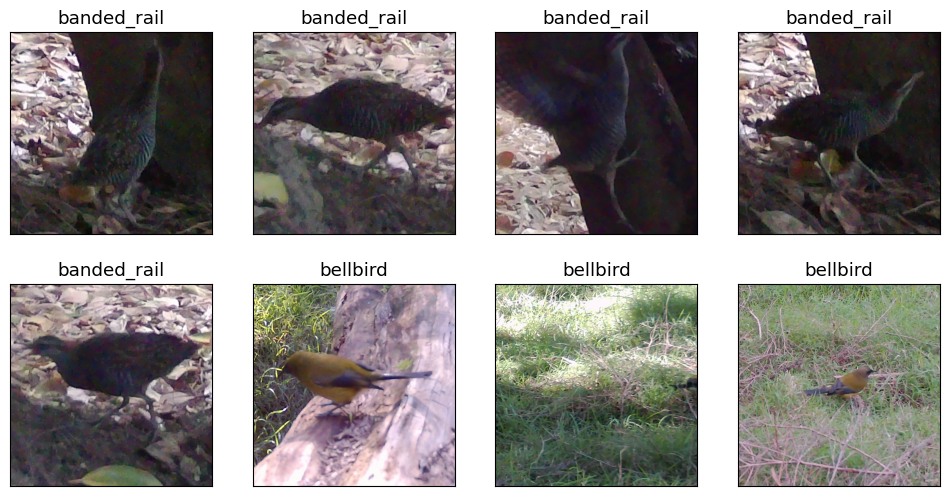

In [17]:
images = val_viewer.show_batch()

## Examine the training performance
Taking a look at some of the taining images, with the data augmentation included

In [18]:
train_viewer = BatchViewer(train_loader, 
                           targets_dict, 
                           displayer=img_displayer, 
                           batch_size=16)

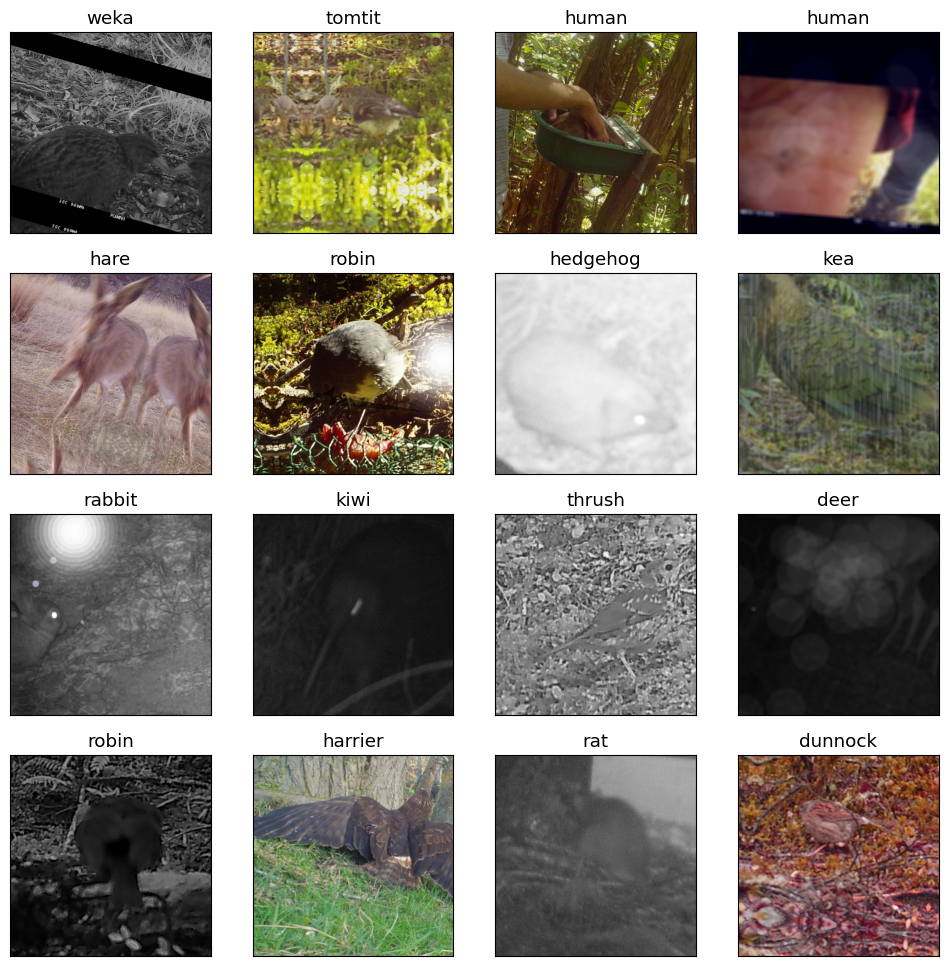

In [19]:
images=train_viewer.show_batch()

Look at logged training metrics logged during the training.

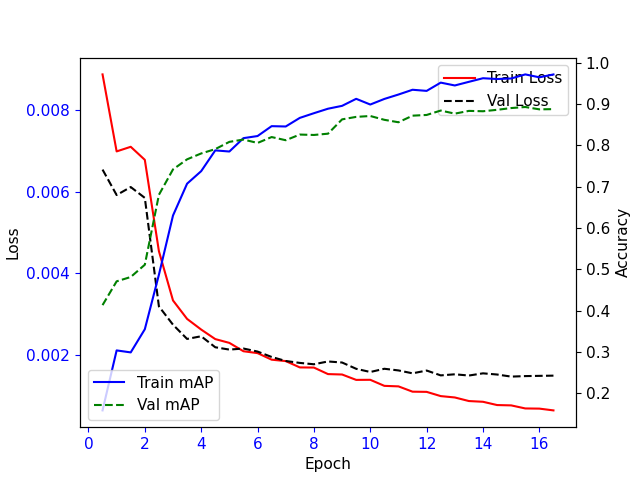

In [20]:
display(Image(str(paths.train_metrics_pth), alt="Training metrics recorded each half-epoch"))

Now looking at the accuracy using macro Average Precision Score (mAP) for the predictions from the last training batch by class, along with their frequencies.  These numbers are expected to be quite low, as they include the effects of image augmentation.

In [21]:
train_pred = pd.read_pickle(paths.pickle_paths['train_pred_df'])
train_true = pd.read_pickle(paths.pickle_paths['train_target_df'])
if (train_pred.shape[0] == train_true.shape[0]) and (train_pred.shape[0] >=20):
    _, _ = plot_map_by_class(train_true, train_pred, min_samples=5)
else: print(f'There were only {train_pred.shape[0]} rows in the predictions dataframe, too few for mAP scores')

From counting loop: Removing 1 species, 4.0 instances: [('rosella', 4.0)], 
Removing 1 classes as they have less than 5 samples
Also removing 4 image instances, as they were from those classes


And doing the same for the final validation batch.  These images were from cameras not used in training, but the result is not fully independent as the decision to stop training was optimised for this data, and some cameras will have been from nearby locations to those used for training.

In [22]:
val_labels_numeric = val_labels_df.iloc[:,2:]
val_preds_numeric = val_preds_df.iloc[:,2:]

names, scores = plot_map_by_class(val_labels_numeric, val_preds_numeric, min_samples=5)
val_accuracy_df = pd.DataFrame({'Name': names, 'macroAveragePrecision': scores})
val_accuracy_df.to_csv(paths.class_acc_pth, index=False)

From counting loop: Removing 21 species, 12 instances: [('banded_dotterel', 1), ('black_billed_gull', 4), ('canada_goose', 0), ('chicken', 0), ('crake', 0), ('fiordland_crested_penguin', 0), ('grey_warbler', 0), ('horse', 0), ('kaka', 0), ('kereru', 0), ('little_blue_penguin', 0), ('myna', 0), ('nz_falcon', 0), ('paradise_duck', 1), ('shore_plover', 0), ('spurwing_plover', 0), ('stilt', 0), ('swan', 2), ('takahe', 0), ('white_faced_heron', 4), ('wrybill', 0)], 
Removing 21 classes as they have less than 5 samples
Also removing 12 image instances, as they were from those classes


In [23]:
overall_acc_1, balanced_acc_1, map_1, f1_1 = get_metrics(val_labels_numeric, val_preds_numeric)

From counting loop: Removing 21 species, 12 instances: [('banded_dotterel', 1), ('black_billed_gull', 4), ('canada_goose', 0), ('chicken', 0), ('crake', 0), ('fiordland_crested_penguin', 0), ('grey_warbler', 0), ('horse', 0), ('kaka', 0), ('kereru', 0), ('little_blue_penguin', 0), ('myna', 0), ('nz_falcon', 0), ('paradise_duck', 1), ('shore_plover', 0), ('spurwing_plover', 0), ('stilt', 0), ('swan', 2), ('takahe', 0), ('white_faced_heron', 4), ('wrybill', 0)], 
Removing 21 classes as they have less than 5 samples
Also removing 12 image instances, as they were from those classes
Overall accuracy score for classes with more than 5 samples is: 0.930
Balanced accuracy score for classes with more than 5 samples is: 0.863
macro Average Precision Score for classes with more than 5 samples is: 0.923
macro F1 Score for classes with more than 5 samples is: 0.877


From counting loop: Removing 16 species, 0 instances: [('canada_goose', 0), ('chicken', 0), ('crake', 0), ('fiordland_crested_penguin', 0), ('grey_warbler', 0), ('horse', 0), ('kaka', 0), ('kereru', 0), ('little_blue_penguin', 0), ('myna', 0), ('nz_falcon', 0), ('shore_plover', 0), ('spurwing_plover', 0), ('stilt', 0), ('takahe', 0), ('wrybill', 0)], 
Removing 16 classes as they have less than 1 samples
Also removing 0 image instances, as they were from those classes


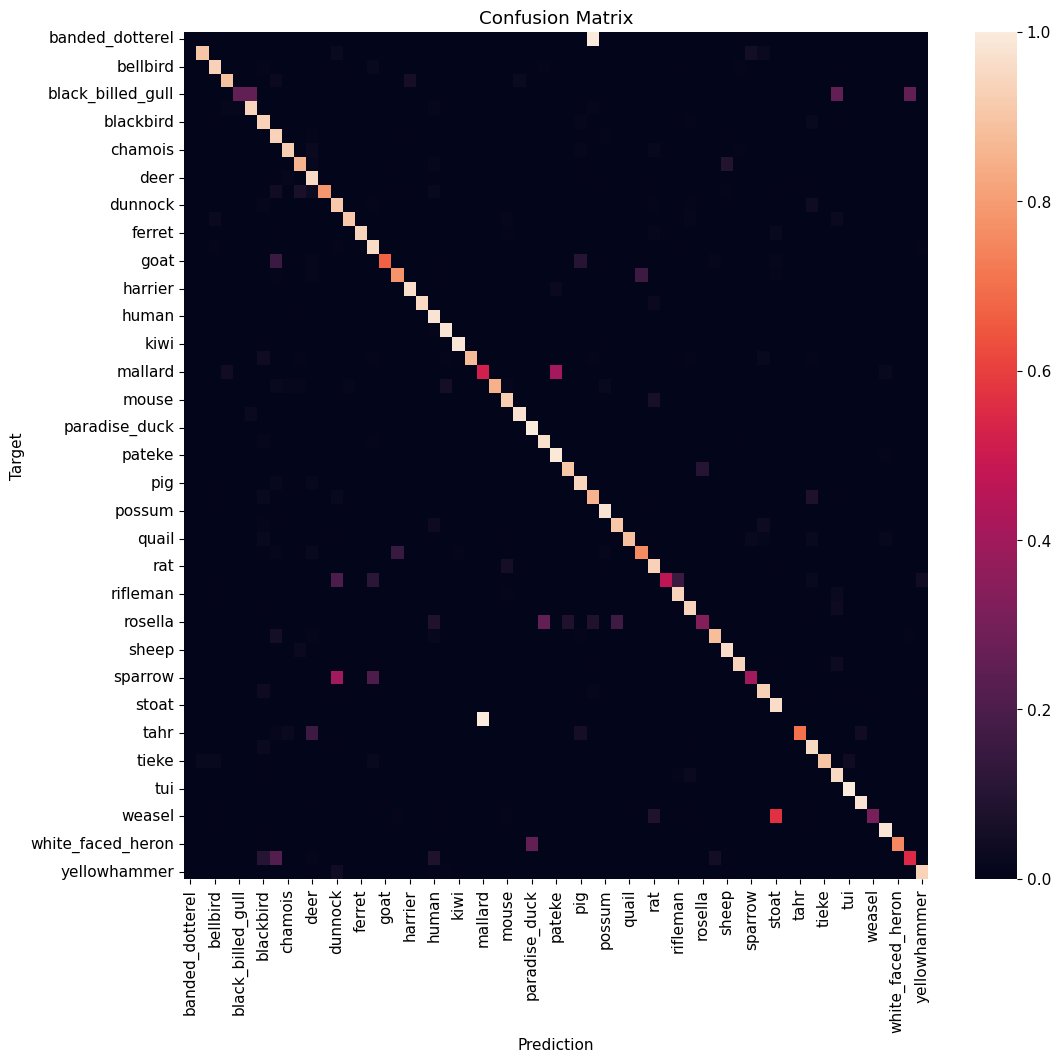

In [24]:
build_cf_matrix(val_labels_numeric, 
                val_preds_numeric,
                cf_norm_pth=paths.cf_matrix_norm_pth, 
                cf_pth=paths.cf_matrix_pth,
                cf_fig_pth=paths.cf_matrix_fig_pth)

Taking a look at how the data is presented during inference

In [25]:
table = make_output_table(val_preds_df, targets_dict)
pd.set_option('display.width', 90)
pd.set_option('display.max_columns', 15)
pd.set_option('display.max_colwidth', 30)
table.iloc[:, :12].head(3)

,Target,Prediction,Probability,Second Pred,Second Prob,Third Pred,Third Prob,File_Path,banded_dotterel,banded_rail,bellbird,black_backed_gull
0,banded_rail,banded_rail,0.8020,cat,0.0264,mouse,0.0257,/home/olly/Desktop/Alita/D...,0.0000,0.8020,0.0003,0.0000
1,banded_rail,banded_rail,1.0000,goat,0.0000,hare,0.0000,/home/olly/Desktop/Alita/D...,0.0000,1.0000,0.0000,0.0000
2,banded_rail,banded_rail,0.4724,mouse,0.1550,kea,0.1500,/home/olly/Desktop/Alita/D...,0.0005,0.4724,0.0221,0.0006


## Load the model and check the model

In [26]:
print(f'Allocated GPU memory at this moment {torch.cuda.memory_allocated()} Bytes')

Allocated GPU memory at this moment 0 Bytes


Show predictions from one batch

In [27]:
model = get_model(paths.weights_pth, 
                  len(targets_list), 
                  model_name=train_cfg.MODEL_NAME, 
                  head_name=train_cfg.HEAD_NAME)

The path to the weights file is /home/olly/Desktop/Alita/Data/Experiments/Exp_46/Runs/Run_21/Models/Run_21_weights/Run_21_best_weights.pt
The model name is tf_efficientnetv2_s.in21k
The classfier head name is ClassifierHead
There are 1280 input features to the classifier head and 77 outputs


In [28]:
predictor = BatchPredictor(val_loader, model, device, activation='Sigmoid')

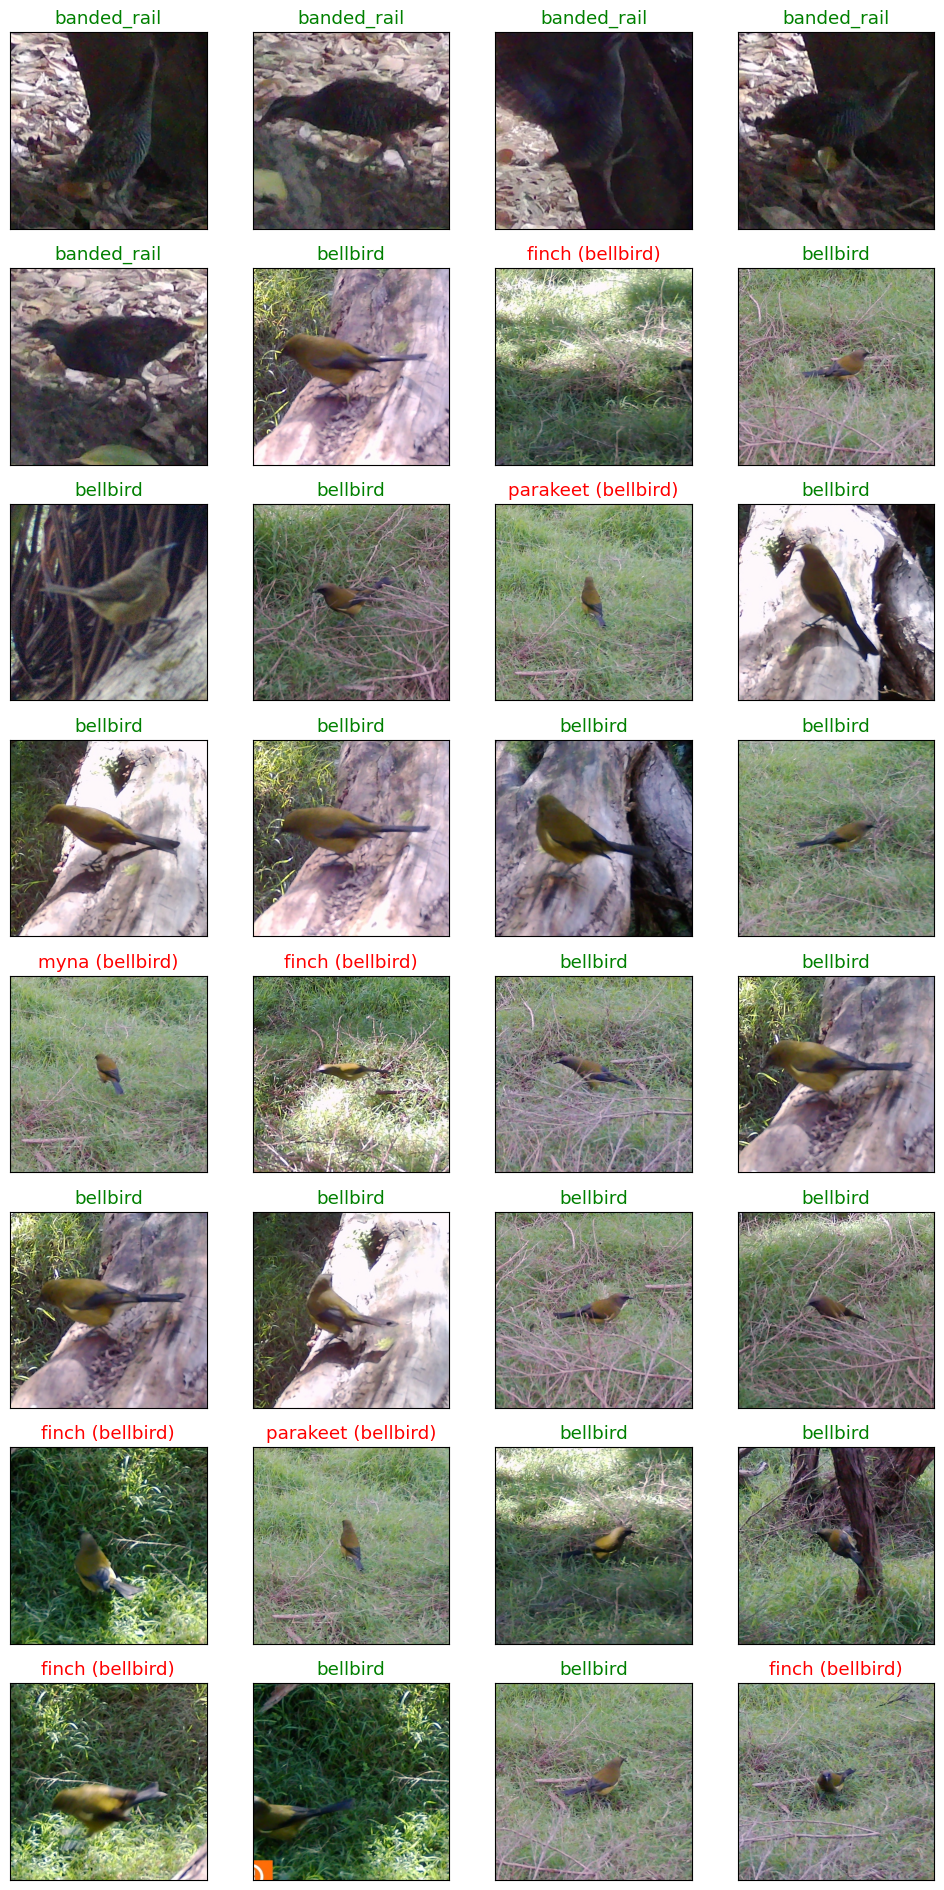

In [29]:
targets, probs, images = predictor.predict_batch()
show_predictions(targets, probs, images, targets_dict, displayer=img_displayer)

## Evaluation on the test set
The randomly selected test images evaluated earlier could potentially be correlated to the training data as they come from the same general area and time of year as the training data.  This is a known challenge with trail cam image classification.  To get a more reliable performance assessment we have held some specific camera regions out of the training routine entirely.  The following test locations were used for this:

In [30]:
train_cfg.INDEPENDENT_TEST_ONLY

['N01',
 'BWS',
 'EBF',
 'EM1',
 'ES1',
 'EL1',
 'ES1',
 'N02',
 'N04',
 'N06',
 'N08',
 'OTR',
 'WRO']

The next cell runs the inference script, exactly as it would do in real use.  Cropping from large images with MegaDetector first.  The parquet file produced will be exactly the shape and classes defined in training and in the inference notebook (which must match in their default settings if not running from a common settings file).

However this script knows nothing about the class file names used for the test set, so those names will need to be cleaned and re-named as per the same settings to be useful for evaluation, prior to the one-hot encoding step which puts them into a dataframe.

In [31]:
paths.image_dir

PosixPath('/home/olly/Desktop/Alita/Data/Experiments/Exp_46/Inputs/Cropped_Images')

In [32]:
def balance_and_clean_test_images(all_img_path,
                                  clean_data_path,
                                  cfg,
                                  class_list,
                                  max_class_location=100,
                                  max_class=400,
                                  verbose=True):
    '''
    Balance the test dataset so none of the various classes are over-represented
    remove duplicates, 
    correct any issues with naming to match those of the classifier
    '''

    labels_df, md_output_pth = find_dataframe(all_img_path, 
                                              class_list,
                                              resize_method = 'md_crop',
                                              detector_name = 'md_v5',
                                              class_name_change = cfg.CLASS_NAME_CHANGE,
                                              class_joins = cfg.CLASS_JOINS,
                                              verbose = verbose)

    recalculate = True  #Initialising recalculate
    hash_path = all_img_path / 'peceptual_hashes.h5'
    hash_pair_distances = all_img_path / 'hash_pair_distances.h5'

    if hash_path.exists() and hash_pair_distances.exists():
        original_length = len(labels_df)
        print(f'The original length of the image dataset before removing duplicates is {original_length}')
        with h5py.File(hash_path, "r") as f:
            length = f["keys"].shape[0]  # Get the length without loading data
        if length == original_length:
            recalculate = False
            print("Length of hash dataset is:", length)
            print('Not recalculating hash pairs as the revious hashing included all images')

    print(f'Before hash removal the length was {len(labels_df)}')
    df, duplicate_pairs = remove_duplicates_by_hash(labels_df,
                                            h5_path=hash_path,
                                            hash_dist_h5_path = hash_pair_distances,
                                            cols=['Species','Location'],
                                            min_distance=50,
                                            recalculate=recalculate,
                                            verbose=verbose,
                                            )
    print(f'After hash removal the length was {len(df)}')

    flattened_list = [(key, value) for key, values in cfg.CLASS_JOINS.items() for value in values]
    inv_merge = {val:key for (key, val) in flattened_list}
    rename_dict = {**cfg.CLASS_NAME_CHANGE, **inv_merge}
    df['Targets'] = df['Targets'].replace(to_replace=rename_dict)  #value=None
    unique_targets = df['Targets'].unique()
    unused_classes = set(unique_targets) - set(class_list)
    df = df[~df['Targets'].isin(unused_classes)]

    df=limit_randomly(df,
                      cols=['Targets','Location'],
                      limit=max_class_location)
    print(f'{len(df)} lines left after limiting to {max_class_location} images per class-location')

    def random_select(group, max_to_keep):
        n_rows = min(max_to_keep, len(group))
        return group.sample(n=n_rows)

    df = df.groupby('Targets', group_keys=False).apply(random_select, max_class)
    df.reset_index(drop=True, inplace=True)

    print(f'{len(df)} lines left after limiting to {max_class} images per class')

    targets = list(df['Targets'])
    names = [Path(path).name for path in list(df['File_Path'])]
    new_paths = [str(clean_data_path / target / name) for target, name in zip(targets, names)]
    df['New_Path'] = new_paths

    return df

def repopulate_test_folder(df, test_fldr_path):
    def copy_file(src, dst):
        """Copy a file from src to dst, ensuring parent directories exist."""
        src_path = Path(src)
        dst_path = Path(dst)
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        copy2(src_path, dst_path)  # Preserve metadata

    shutil.rmtree(test_fldr_path)
    test_fldr_path.mkdir(parents=True, exist_ok=True)
    Parallel(n_jobs=4)(delayed(copy_file)(src, dst) for src, dst in zip(df["File_Path"], df["New_Path"]))

#Currently MegaDetector crashes on Linux, so workaround is to manually transfer the test dir from Windows
if sys.platform != 'linux':
    new_test_df = balance_and_clean_test_images(paths.independent_image_dir, paths.test_image_dir, train_cfg, targets_list, verbose=VERBOSE)
    image_extensions = {".jpg", ".jpeg", ".png", ".gif", ".bmp", ".tiff", ".webp"}
    image_count = sum(1 for file in paths.test_image_dir.rglob("*") if file.suffix.lower() in image_extensions) 
    if image_count != len(new_test_df):
        repopulate_test_folder(new_test_df, paths.test_image_dir)

In [33]:
inferred_df, speed = Inference.main(settings_pth, 
                                    external_image_dir=paths.test_image_dir,
                                    empty_detect_threshold=EMPTY_DETECT_THRESHOLD,
                                    empty_classify_threshold=EMPTY_CLASSIFY_THRESHOLD,
                                    num_workers=2, 
                                    verbose=VERBOSE)
cuda_data = torch.cuda.memory_allocated()
print(f'There is {cuda_data} Bytes allocated data left in the GPU memory after inference on the independent dataset')

Using settings file: Exp_46, run: Run_21
Exp_46/Runs/Run_21/Models/Run_21_weights/Run_21_best_weights.pt is a valid PyTorch weights file for the classifier
olly/Desktop/Alita/Alita_Deployment/Models/md_v5a.0.0.pt is the weights file for the MegaDetector
Checking for suitable media files (.jpg, .jpeg, .mp4, .avi & .mov)
looking in /home/olly/Desktop/Alita/Data/Test_Images


6812it [00:00, 137380.63it/s]

6765 media files found for classification
Searching for video files
Extracting 0 video files to jpg images
Total video processing time was 9.5367431640625e-07
The following list contains all the possible output classes from the classifier
['banded_dotterel', 'banded_rail', 'bellbird', 'black_backed_gull', 'black_billed_gull', 'black_fronted_tern', 'blackbird', 'canada_goose', 'cat', 'chamois', 'chicken', 'cow', 'crake', 'deer', 'dog', 'dunnock', 'fantail', 'ferret', 'finch', 'fiordland_crested_penguin', 'goat', 'grey_warbler', 'hare', 'harrier', 'hedgehog', 'horse', 'human', 'kaka', 'kea', 'kereru', 'kiwi', 'little_blue_penguin', 'magpie', 'mallard', 'morepork', 'mouse', 'myna', 'nz_falcon', 'oystercatcher', 'paradise_duck', 'parakeet', 'pateke', 'pheasant', 'pig', 'pipit', 'possum', 'pukeko', 'quail', 'rabbit', 'rat', 'redpoll', 'rifleman', 'robin', 'rosella', 'sealion', 'sheep', 'shore_plover', 'silvereye', 'sparrow', 'spurwing_plover', 'starling', 'stilt', 'stoat', 'swan', 'tahr', '

The following list contains all the unique folder labels in your file structure that match class names
['banded_dotterel' 'bellbird' 'blackbird' 'cat' 'cow' 'deer' 'dog' 'dunnock' 'fantail' 'ferret' 'goat' 'hare' 'harrier' 'hedgehog' 'human' 'kaka' 'kea' 'kereru' 'kiwi' 'magpie' 'morepork' 'mouse' 'paradise_duck' 'pheasant' 'pig' 'pipit' 'possum' 'rabbit' 'rat' 'redpoll' 'rifleman' 'robin' 'silvereye' 'stoat' 'thrush'
 'tomtit' 'tui' 'wallaby' 'weasel' 'weka' 'yellowhammer']
Length of the labels dataframe: 6765
                       File_Path  Mega_Class  Confidence     x_min     y_min     Width  \
0  /home/olly/Desktop/Alita/D...           0    0.914475  0.026042  0.200798  0.077381   
1  /home/olly/Desktop/Alita/D...           0    0.875870  0.024926  0.583112  0.170387   
2  /home/olly/Desktop/Alita/D...           0    0.921437  0.610863  0.472074  0.058780   

     Height          Species Location          Targets  
0  0.170213  banded_dotterel  unknown  banded_dotterel  
1  0.123

100%|██████████| 6765/6765 [02:35<00:00, 43.52it/s]


The classifier processed 6765 samples in 155.39 seconds
That is a mean of 43.54 images per second
                                        Targets            Date_Time       Prediction  \
/home/olly/Desktop/Alita/Da...  banded_dotterel  12/09/2020 10:38:27  banded_dotterel   
/home/olly/Desktop/Alita/Da...         bellbird  01/01/2018 00:00:02        silvereye   
/home/olly/Desktop/Alita/Da...         bellbird  01/01/2018 00:00:04         bellbird   
/home/olly/Desktop/Alita/Da...         bellbird  01/01/2018 00:00:02         bellbird   
/home/olly/Desktop/Alita/Da...         bellbird  04/01/2023 14:21:53         bellbird   

                                Probability      Second_Pred  Second_Prob    Third_Pred  \
/home/olly/Desktop/Alita/Da...       0.9101  spurwing_plover       0.0153         pipit   
/home/olly/Desktop/Alita/Da...       0.8582            finch       0.0708      bellbird   
/home/olly/Desktop/Alita/Da...       0.9290            finch       0.0096      parakeet   
/ho

In [34]:
inferred_df.iloc[:,:17].head(3)

,Date_Time,Encounter_Start,Encounter,Max_Prob,Targets,Prediction,Probability,...,Third_Prob,Crop,x_min,y_min,Width,Height,Confidence
File_Path,,,,,,,,,,,,,,,
/home/olly/Desktop/Alita/Data/Test_Images/banded_dotterel/627B570A-0739-4F2C-BB16-83C7404C197C.JPG,12/09/2020 10:38:27,10:38:27,banded_dotterel,0.910,banded_dotterel,banded_dotterel,0.910,...,0.012,"[0.0, 0.0864, 0.2232, 0.4854]",0.026,0.201,0.077,0.170,0.914
/home/olly/Desktop/Alita/Data/Test_Images/bellbird/E8236B7E-394A-4F5F-9AE7-5950265B14AC.JPG,01/01/2018 00:00:00,00:00:00,bellbird,0.998,bellbird,dunnock,0.362,...,0.050,"[0.0807, 0.5007, 0.3039, 0...",0.138,0.579,0.109,0.242,0.888
/home/olly/Desktop/Alita/Data/Test_Images/bellbird/B57D2B94-16D1-4E8C-9096-459E75CE273C.JPG,01/01/2018 00:00:00,00:00:00,bellbird,0.998,bellbird,bellbird,0.990,...,0.000,"[0.385, 0.2926, 0.6083, 0....",0.438,0.447,0.118,0.090,0.923


In [35]:
inferred_df.iloc[:,17:].head(1)

,banded_dotterel,banded_rail,bellbird,black_backed_gull,black_billed_gull,black_fronted_tern,blackbird,...,wallaby,weasel,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
File_Path,,,,,,,,,,,,,,,
/home/olly/Desktop/Alita/Data/Test_Images/banded_dotterel/627B570A-0739-4F2C-BB16-83C7404C197C.JPG,0.91,0.0,0.0,0.003,0.001,0.0,0.0,...,0.0,0.0,0.0,0.0,0.006,0.0,0.0


Let's check out how often a class is 'unknown' because the prediction score was below UNKNOWN_THRESHOLD

In [36]:
inferred_df[inferred_df['Encounter'] == 'unknown'].iloc[:, :8]

,Date_Time,Encounter_Start,Encounter,Max_Prob,Targets,Prediction,Probability,Second_Pred
File_Path,,,,,,,,


In [37]:
print(f"There are {inferred_df['Targets'].nunique()} unique targets based on folder names")
print(f'There are {inferred_df.iloc[:,17:].shape[1]} unique targets in the model predictions')
print(f'There are {inferred_df.shape[0]} rows in the model output file')
unique_targets = inferred_df['Targets'].unique()
targets_no_column = set(unique_targets) - set(inferred_df.columns)
print(f'These are the targets that do not have a matching prediction class: {targets_no_column}')
for mystery_targ in targets_no_column:
    no_col_count = (inferred_df['Targets'] == mystery_targ).sum()
    print(f"There are {no_col_count} rows with the unmatched target of: {mystery_targ}")

There are 41 unique targets based on folder names
There are 77 unique targets in the model predictions
There are 6765 rows in the model output file
These are the targets that do not have a matching prediction class: set()


In [38]:
file_paths = random.sample(inferred_df.index.tolist(), 20) #using file paths as the index for the df
for idx in range(4):
    print(file_paths[idx])

/home/olly/Desktop/Alita/Data/Test_Images/blackbird/4d2a5cdf-f6be-45fb-beb8-2afba0701175.JPG
/home/olly/Desktop/Alita/Data/Test_Images/thrush/c3ee17e4-d9e2-40fb-b442-c5249af30d8b.JPG
/home/olly/Desktop/Alita/Data/Test_Images/weka/DC49AF96-1276-469B-997C-1F3DE61ACB6B.JPG
/home/olly/Desktop/Alita/Data/Test_Images/kea/D73C221C-4FC6-4DBA-ABF6-1F159D197442.JPG


Purple = The classifier crop  
Blue = The MegaDetector Bounding box

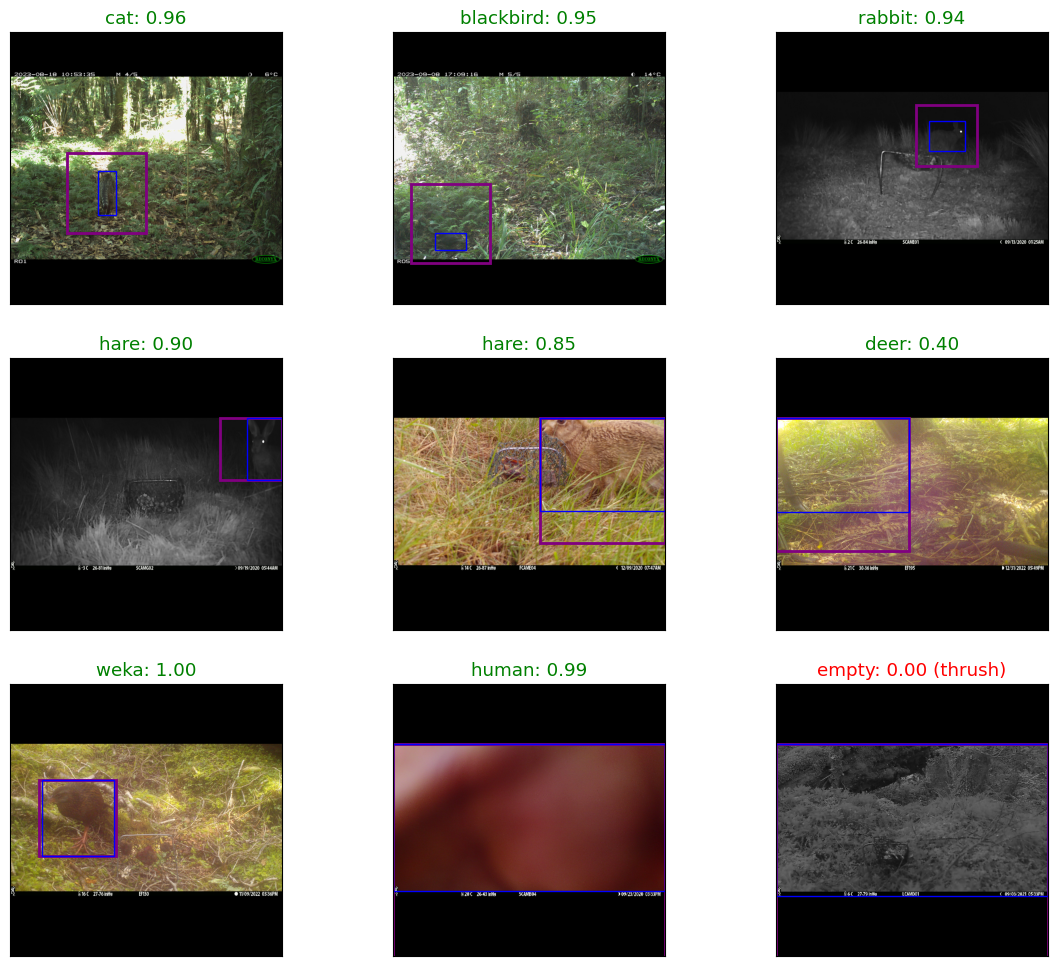

In [39]:
show_inferred_imgs(inferred_df, 
                   num_ims=9, 
                   rescale=img_cfg.RESCALE, 
                   crop_size=img_cfg.CROP_SIZE, 
                   buffer=img_cfg.BUFFER)

In [40]:
inf_preds_df = inferred_df.iloc[:,17:]
#inf_preds_df.to_csv(paths.balanced_preds_path)
inf_classes = inf_preds_df.columns.tolist()
inf_preds_df.head(3)

,banded_dotterel,banded_rail,bellbird,black_backed_gull,black_billed_gull,black_fronted_tern,blackbird,...,wallaby,weasel,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
File_Path,,,,,,,,,,,,,,,
/home/olly/Desktop/Alita/Data/Test_Images/banded_dotterel/627B570A-0739-4F2C-BB16-83C7404C197C.JPG,0.91,0.0,0.000,0.003,0.001,0.0,0.000,...,0.0,0.0,0.0,0.0,0.006,0.0,0.0
/home/olly/Desktop/Alita/Data/Test_Images/bellbird/E8236B7E-394A-4F5F-9AE7-5950265B14AC.JPG,0.00,0.0,0.285,0.000,0.000,0.0,0.047,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0
/home/olly/Desktop/Alita/Data/Test_Images/bellbird/B57D2B94-16D1-4E8C-9096-459E75CE273C.JPG,0.00,0.0,0.990,0.000,0.000,0.0,0.000,...,0.0,0.0,0.0,0.0,0.000,0.0,0.0


In [41]:
min_samples=40
inf_targs_df = pd.get_dummies(inferred_df['Targets']).astype(int)
inf_targs_df.index = inf_preds_df.index
all_classes = list(inf_preds_df.columns)
missing_classes = list(set(all_classes).difference(set(inferred_df.Targets.unique())))

In [42]:
inf_targs_df[missing_classes] = 0
inf_targs_df = inf_targs_df[all_classes]
rows_with_no_target = inf_targs_df.index[inf_targs_df.sum(axis=1) == 0] 
print(Colour.S + 'Rows with no target: ' + Colour.E, len(rows_with_no_target))
targets, predictions = remove_rare_classes(inf_targs_df, inf_preds_df, 40)
num_independent_species = predictions.shape[1]
num_independent_images = predictions.shape[0]
print(f'The shape of the final targets, predictions dataframe is {targets.shape}, {predictions.shape}')
overall_acc_2, balanced_acc_2, map_2, f1_2 = get_metrics(targets, predictions, min_samples)

Rows with no target:  0
From counting loop: Removing 49 species, 212 instances: [('banded_dotterel', 1), ('banded_rail', 0), ('bellbird', 23), ('black_backed_gull', 0), ('black_billed_gull', 0), ('black_fronted_tern', 0), ('canada_goose', 0), ('chamois', 0), ('chicken', 0), ('cow', 7), ('crake', 0), ('dog', 9), ('finch', 0), ('fiordland_crested_penguin', 0), ('grey_warbler', 0), ('horse', 0), ('kaka', 1), ('little_blue_penguin', 0), ('magpie', 30), ('mallard', 0), ('morepork', 6), ('myna', 0), ('nz_falcon', 0), ('oystercatcher', 0), ('paradise_duck', 39), ('parakeet', 0), ('pateke', 0), ('pukeko', 0), ('quail', 0), ('rabbit', 35), ('redpoll', 2), ('rosella', 0), ('sealion', 0), ('sheep', 0), ('shore_plover', 0), ('sparrow', 0), ('spurwing_plover', 0), ('starling', 0), ('stilt', 0), ('swan', 0), ('tahr', 0), ('takahe', 0), ('tieke', 0), ('tui', 21), ('weasel', 11), ('white_faced_heron', 0), ('wrybill', 0), ('yellow_eyed_penguin', 0), ('yellowhammer', 27)], 
Removing 49 classes as they h

In [43]:
names, scores = plot_map_by_class(targets, predictions, min_samples=5, height=400)

In [44]:
inf_targs_df.head(3)

,banded_dotterel,banded_rail,bellbird,black_backed_gull,black_billed_gull,black_fronted_tern,blackbird,...,wallaby,weasel,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
File_Path,,,,,,,,,,,,,,,
/home/olly/Desktop/Alita/Data/Test_Images/banded_dotterel/627B570A-0739-4F2C-BB16-83C7404C197C.JPG,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0
/home/olly/Desktop/Alita/Data/Test_Images/bellbird/E8236B7E-394A-4F5F-9AE7-5950265B14AC.JPG,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0
/home/olly/Desktop/Alita/Data/Test_Images/bellbird/B57D2B94-16D1-4E8C-9096-459E75CE273C.JPG,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0


So now let's plot all true positive scores with true negatives

In [45]:
pred_vals = inferred_df[inf_targs_df.columns].values
targ_vals = inf_targs_df.values
positive_scores = (pred_vals * targ_vals).flatten()
negative_scores = (pred_vals * (1-targ_vals)).flatten()

tp_scores = positive_scores[positive_scores != 0]
tn_scores = negative_scores[negative_scores != 0]

print(Colour.S + 'The mean prediction value for true positives is: ' + Colour.E + f'{tp_scores.mean():.2}')
print(Colour.S + 'The mean prediction value for true negatives is: ' + Colour.E + f'{tn_scores.mean():.2}')

The mean prediction value for true positives is: 0.81
The mean prediction value for true negatives is: 0.021


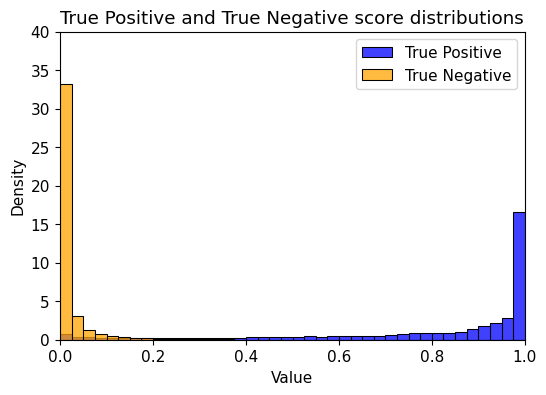

In [46]:
%matplotlib inline
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")
plot_two_distributions(tp_scores, 
                       tn_scores, 
                       label1='True Positive', 
                       label2='True Negative', 
                       bins=40, 
                       x_max=1, 
                       y_max=40)

So here a threshold of 0.2 would have almost no false positives, but a significant number of false positives.  We would like to shift the true positive distribution so there is minimal overlap.

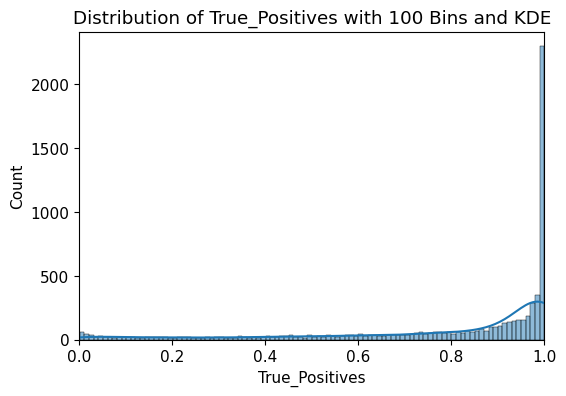

In [47]:
def plot_continuous(df, column_name, x_max=None, x_min=None, bins=None):
    plt.figure(figsize=(6, 4))
    ax = sns.histplot(df[column_name], bins=bins, kde=True)
    plt.title(f'Distribution of {column_name} with {bins} Bins and KDE')
    plt.xlabel(column_name)
    ax.set(xlim=(x_min, x_max) if x_min is not None and x_max is not None else None)
    plt.ylabel('Count')
    plt.show()

plot_continuous(pd.DataFrame(tp_scores, columns=['True_Positives']), 'True_Positives', x_min=0, x_max=1, bins=100)

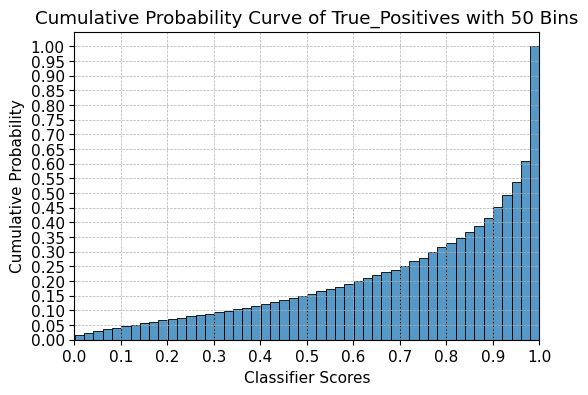

In [48]:
plot_cumulative_probability(pd.DataFrame(tp_scores, columns=['True_Positives']), 'True_Positives', x_min=0, x_max=1, bins=50)

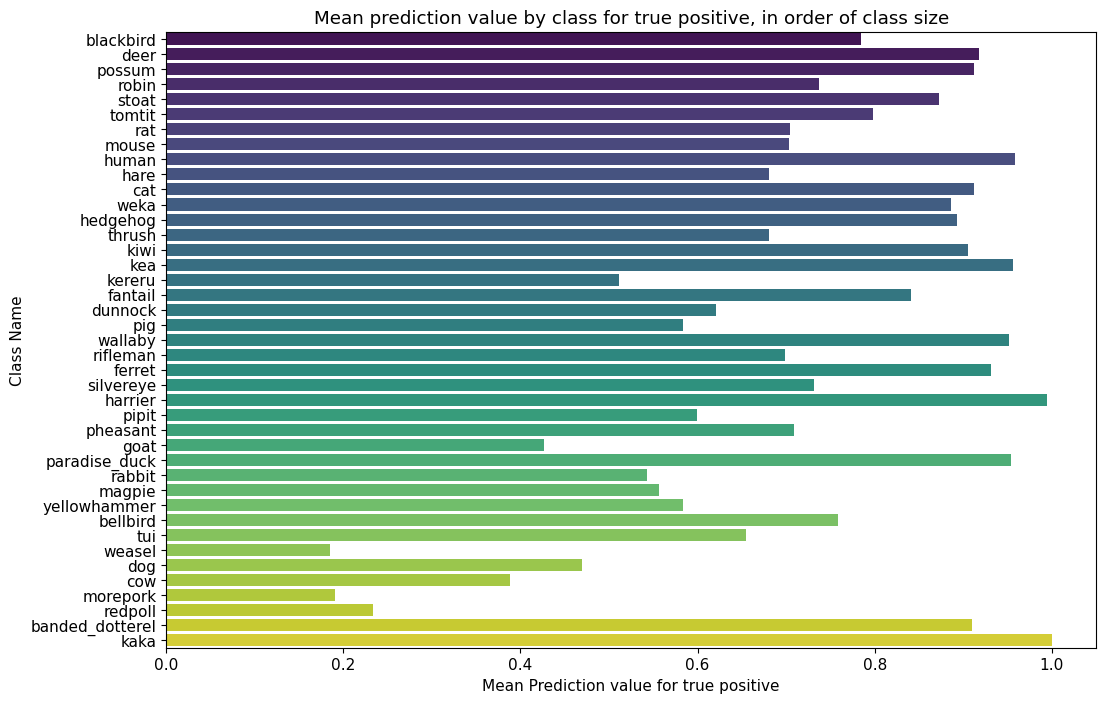

In [49]:
plot_prediction_means(inferred_df, positive=True)

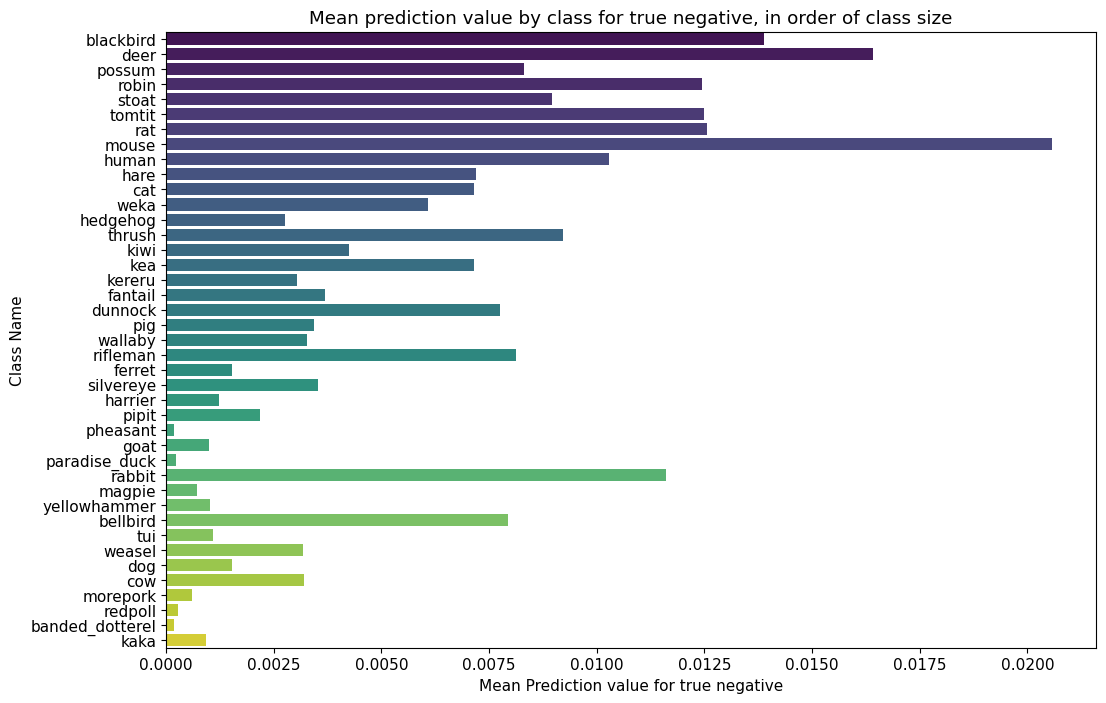

In [50]:
plot_prediction_means(inferred_df, positive=False)

The mean for true positives is 0.9049999713897705
The mean for true negatives is 0.0042548407800495625


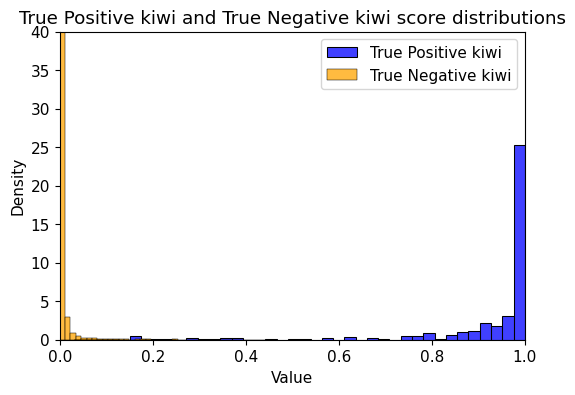

In [51]:
if 'kiwi' in inf_classes:
    positive_mean, negative_mean = predictions_by_class('kiwi', inferred_df, show_results=True)

The mean for true positives is 0.956487238407135
The mean for true negatives is 0.007144855801016092


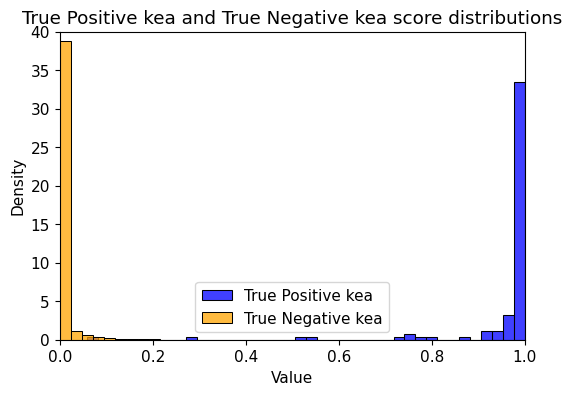

In [52]:
if 'kea' in inf_classes:
    positive_mean, negative_mean = predictions_by_class('kea', inferred_df, show_results=True)

The mean for true positives is 0.9100000262260437
The mean for true negatives is 0.00018494973483029753


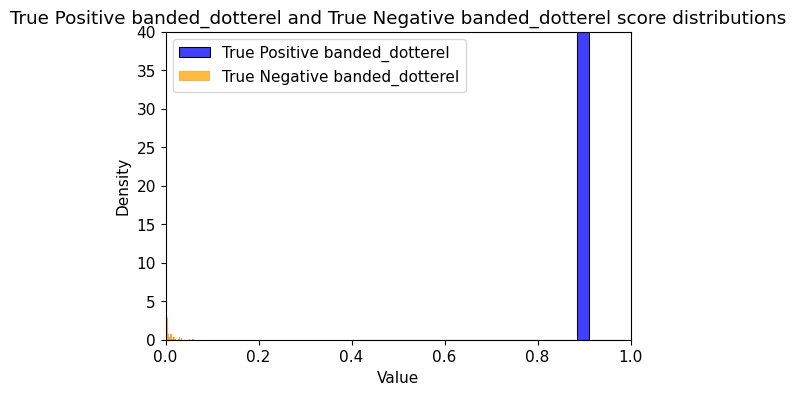

In [53]:
if 'banded_dotterel' in inf_classes:
    _, _ = predictions_by_class('banded_dotterel', inferred_df, show_results=True)

The mean for true positives is 0.7044299840927124
The mean for true negatives is 0.012551925145089626


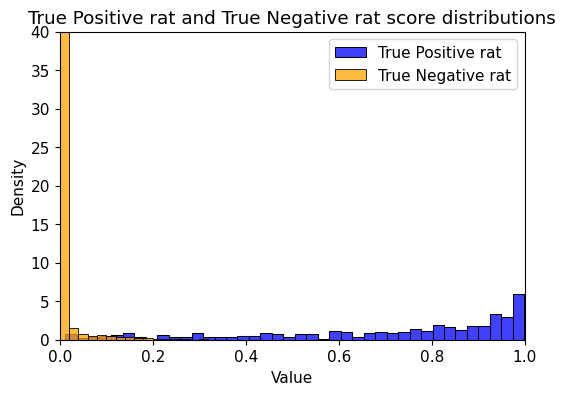

In [54]:
if 'rat' in inf_classes:
    _, _ = predictions_by_class('rat', inferred_df, show_results=True)

The mean for true positives is 0.7028875946998596
The mean for true negatives is 0.020568735897541046


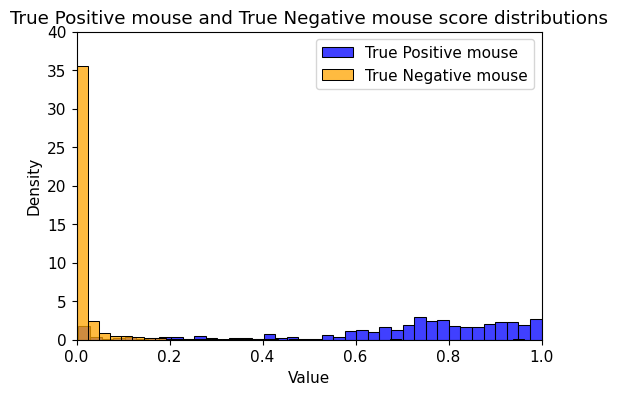

In [55]:
if 'mouse' in inf_classes:
    _, _ = predictions_by_class('mouse', inferred_df, show_results=True)

The mean for true positives is 0.9115331172943115
The mean for true negatives is 0.007142879068851471


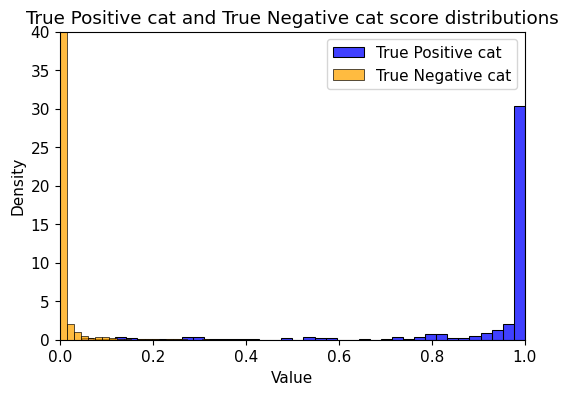

In [56]:
if 'cat' in inf_classes:
    _, _, predictions_by_class('cat', inferred_df, show_results=True)

The mean for true positives is 0.872112512588501
The mean for true negatives is 0.00894972588866949


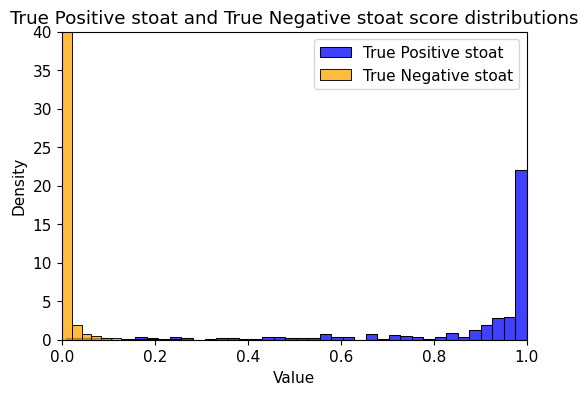

In [57]:
if 'stoat' in inf_classes:
    _, _ = predictions_by_class('stoat', inferred_df, show_results=True)

The mean for true positives is 0.4266341030597687
The mean for true negatives is 0.0010014872532337904


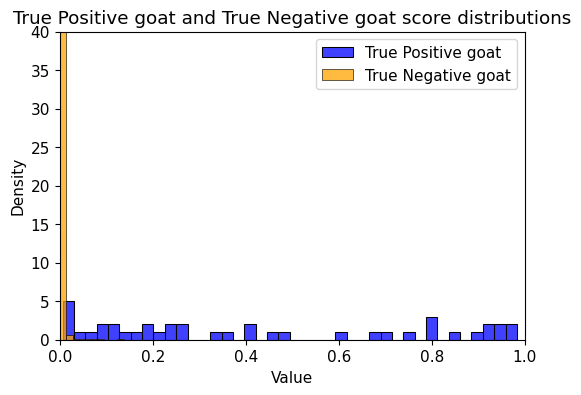

In [58]:
if 'goat' in inf_classes:
    _, _ = predictions_by_class('goat', inferred_df, show_results=True)

The mean for true positives is 0.9116799831390381
The mean for true negatives is 0.008301806636154652


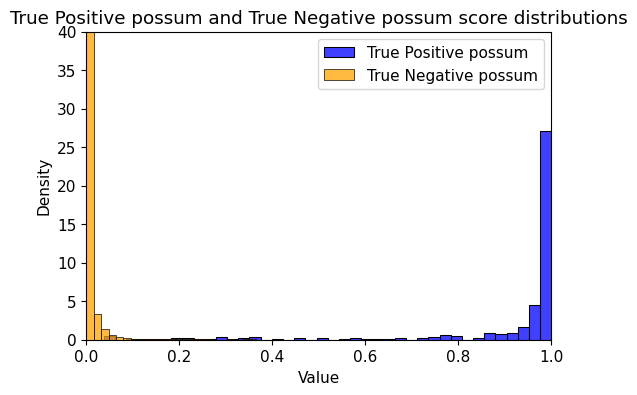

In [59]:
if 'possum' in inf_classes:
    predictions_by_class('possum', inferred_df, show_results=True)

The mean for true positives is 0.9949193000793457
The mean for true negatives is 0.0012188572436571121


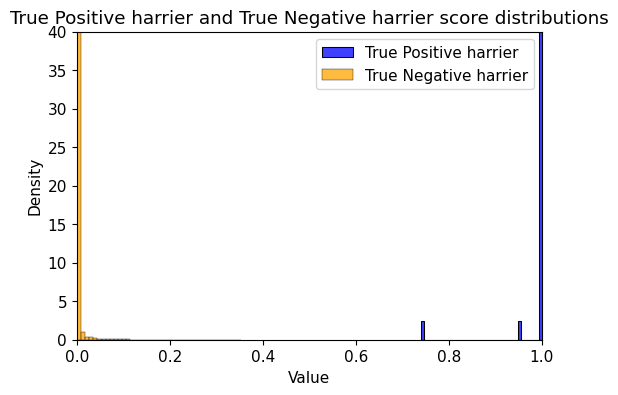

In [60]:
if 'harrier' in inf_classes:
    _, _ = predictions_by_class('harrier', inferred_df, show_results=True)

The mean for true positives is 0.8865794539451599
The mean for true negatives is 0.006072996184229851


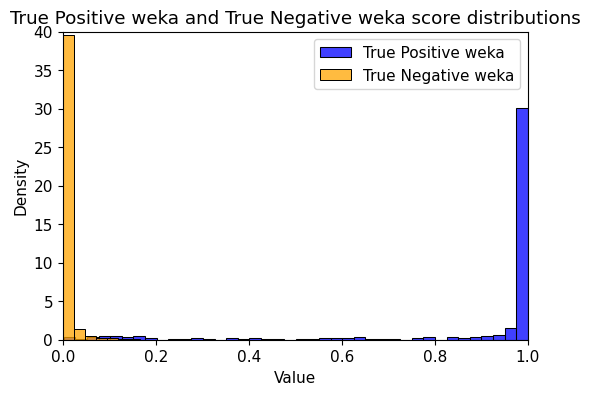

In [61]:
if 'weka' in inf_classes:
    _, _ = predictions_by_class('weka', inferred_df, show_results=True)

Now let's inspect any *unknown* predictions

In [62]:
unknown_df = inferred_df[inferred_df['Encounter'] == 'unknown']
unknown_df.head()

,Date_Time,Encounter_Start,Encounter,Max_Prob,Targets,Prediction,Probability,...,wallaby,weasel,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
File_Path,,,,,,,,,,,,,,,


The most useful figure for the end user is likely to be the balanced accuracy, on the Encounter column.

In [63]:
encounter_df = collate_encounters(inferred_df, possibles=all_classes, all_classes=all_classes)
balanced_acc_img, balanced_acc_enc,  balanced_f1_img, balanced_f1_enc = get_encounter_metrics(encounter_df, min_samples=40)

print('Metrics for all classes in the independent set, by image')
print(Colour.S + 'Balanced Accuracy Score By Image:' + Colour.E, balanced_acc_img)
print(Colour.S + 'Balanced F1 Score by Image:' + Colour.E, balanced_f1_img, '\n')

print('Metrics for all classes in the independent set, by encounter')
print(Colour.S + 'Balanced Accuracy Score By Encounter:' + Colour.E, balanced_acc_enc)
print(Colour.S + 'Balanced F1 Score by Encounter:' + Colour.E, balanced_f1_enc)

Metrics for all classes in the independent set, by image
Balanced Accuracy Score By Image: 0.857
Balanced F1 Score by Image: 0.892 

Metrics for all classes in the independent set, by encounter
Balanced Accuracy Score By Encounter: 0.852
Balanced F1 Score by Encounter: 0.878


These values don't quite match the previous calculations, because the rarer classes were removed from the dataframe, prior to calculation of the maximum probability for each score.
The key point here is we get a boost in useful perfomance by using encounter prediction instead of image prediction.

In [64]:
rodents= ['rat','mouse']
predators = ['rat', 'possum', 'cat', 'stoat', 'weasel']
encounter_df = collate_encounters(inferred_df, possibles=predators, all_classes=all_classes)
_, balanced_acc_enc,  _, balanced_f1_enc = get_encounter_metrics(encounter_df, min_samples=40)

print('Encounter Metrics just for rats, possum, cat, stoat, weasel')
print(Colour.S + 'Balanced Accuracy Score By Encounter:' + Colour.E, balanced_acc_enc)
print(Colour.S + 'Balanced F1 Score by Encounter:' + Colour.E, balanced_f1_enc)

Encounter Metrics just for rats, possum, cat, stoat, weasel
Balanced Accuracy Score By Encounter: 0.918
Balanced F1 Score by Encounter: 0.95


In [65]:
important_animals =infer_cfg.TO_MONITOR 
print(f'Monitored animals: {important_animals}')
important_animal_idxs = {item: i if item in important_animals else 0 for i, item in enumerate(names)}

important_animal_scores = []
for animal in important_animals:
    idx = important_animal_idxs[animal] if animal in names else None
    score = scores[idx] if animal in set(names).intersection(important_animals) else 0
    important_animal_scores.append(score)  
for idx, animal in enumerate(important_animals): 
    print(f'{animal}: {important_animal_scores[idx]:.3f}')

Monitored animals: ['cat', 'mouse', 'possum', 'rat', 'stoat']
cat: 0.993
mouse: 0.878
possum: 0.991
rat: 0.950
stoat: 0.989


Confusion matrix from inference on independent dataset


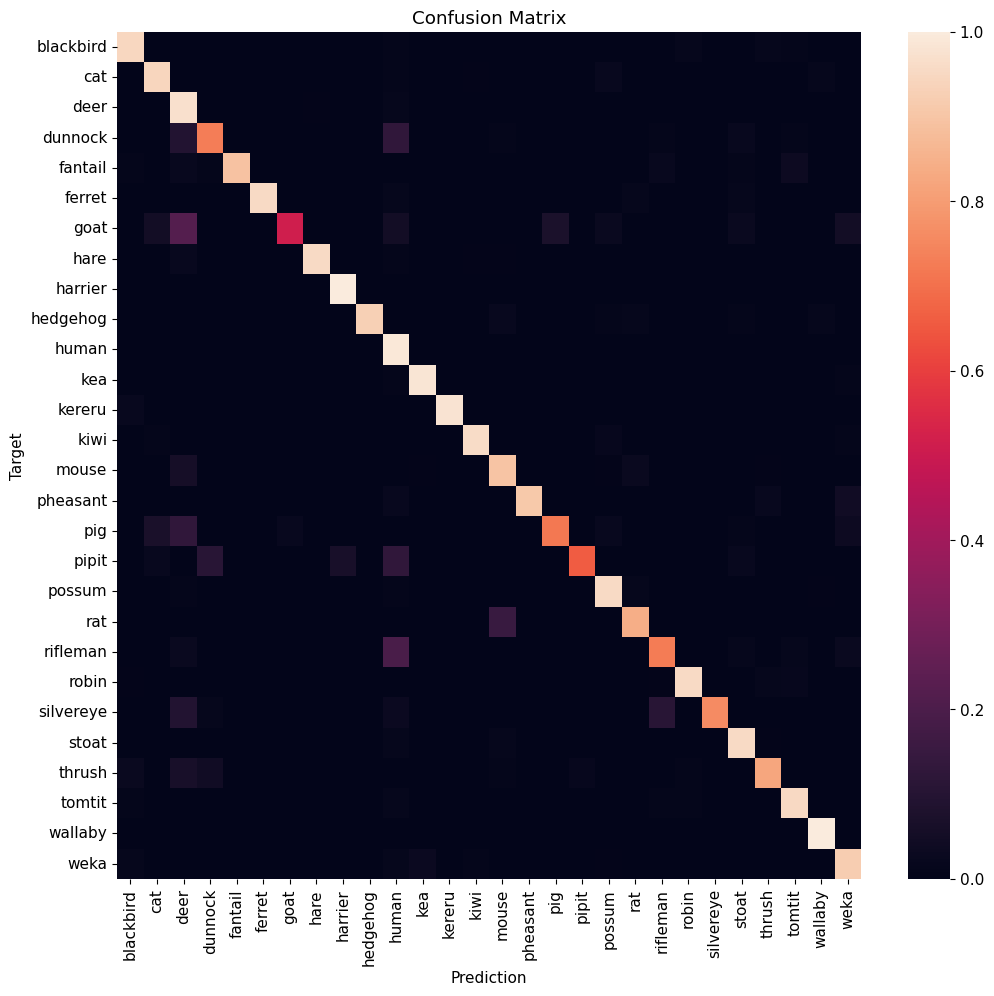

In [66]:
print(Colour.S + 'Confusion matrix from inference on independent dataset' + Colour.E)
build_cf_matrix(targets, predictions)

## Performance on Empties
Up until now, all the focus was on the precision of the multi-class classifier on data where we knew there were animals present.  The overall performance, and practical use depends on the models ability to reject empty images.  However at this point we haven't trained a specific empties class, but rather relied mostly on the MegaDetector Confidence score.

This next section evaluates the overall performance, once a folder of known empty images is added to the evaluation dataset.

In [67]:
extensions = {'.jpg', '.jpeg', '.mp4', '.avi', '.mov'}
num_empties  = len({file_path for file_path in paths.empty_image_dir.rglob('*') if file_path.suffix.lower() in extensions})
num_empties

561

In [68]:
empties_df, speed = Inference.main(settings_pth, 
                                   external_image_dir=paths.empty_image_dir,
                                   empty_detect_threshold=EMPTY_DETECT_THRESHOLD,
                                   empty_classify_threshold=EMPTY_CLASSIFY_THRESHOLD,
                                   num_workers=2,
                                   verbose=VERBOSE)

Using settings file: Exp_46, run: Run_21
Exp_46/Runs/Run_21/Models/Run_21_weights/Run_21_best_weights.pt is a valid PyTorch weights file for the classifier
olly/Desktop/Alita/Alita_Deployment/Models/md_v5a.0.0.pt is the weights file for the MegaDetector
Checking for suitable media files (.jpg, .jpeg, .mp4, .avi & .mov)
looking in /home/olly/Desktop/Alita/Data/Empty_Images


569it [00:00, 72131.99it/s]

561 media files found for classification
Searching for video files
Extracting 0 video files to jpg images
Total video processing time was 4.76837158203125e-07
The following list contains all the possible output classes from the classifier
['banded_dotterel', 'banded_rail', 'bellbird', 'black_backed_gull', 'black_billed_gull', 'black_fronted_tern', 'blackbird', 'canada_goose', 'cat', 'chamois', 'chicken', 'cow', 'crake', 'deer', 'dog', 'dunnock', 'fantail', 'ferret', 'finch', 'fiordland_crested_penguin', 'goat', 'grey_warbler', 'hare', 'harrier', 'hedgehog', 'horse', 'human', 'kaka', 'kea', 'kereru', 'kiwi', 'little_blue_penguin', 'magpie', 'mallard', 'morepork', 'mouse', 'myna', 'nz_falcon', 'oystercatcher', 'paradise_duck', 'parakeet', 'pateke', 'pheasant', 'pig', 'pipit', 'possum', 'pukeko', 'quail', 'rabbit', 'rat', 'redpoll', 'rifleman', 'robin', 'rosella', 'sealion', 'sheep', 'shore_plover', 'silvereye', 'sparrow', 'spurwing_plover', 'starling', 'stilt', 'stoat', 'swan', 'tahr', '

There are 1280 input features to the classifier head and 77 outputs
Image Folder: /home/olly/Desktop/Alita/Data/Empty_Images, (4 images)
Using torch 2.1.2 _CudaDeviceProperties(name='NVIDIA GeForce RTX 3060 Laptop GPU', major=8, minor=6, total_memory=5930MB, multi_processor_count=30)
There are 561 images in the dataloader for inference.


100%|██████████| 561/561 [00:12<00:00, 43.70it/s]


The classifier processed 561 samples in 12.79 seconds
That is a mean of 43.85 images per second
                                Targets            Date_Time Prediction  Probability  \
/home/olly/Desktop/Alita/Da...  unknown  31/08/2020 07:51:56       hare       0.2239   
/home/olly/Desktop/Alita/Da...  unknown  21/03/2021 21:40:32       deer       0.2868   
/home/olly/Desktop/Alita/Da...  unknown  08/07/2021 14:13:21      empty       0.0000   
/home/olly/Desktop/Alita/Da...  unknown  06/07/2023 21:54:45     pateke       0.3897   
/home/olly/Desktop/Alita/Da...  unknown  09/02/2023 05:24:40      empty       0.0000   

                               Second_Pred  Second_Prob Third_Pred  ...  weasel    weka  \
/home/olly/Desktop/Alita/Da...      magpie       0.2089        cow  ...  0.0082  0.0342   
/home/olly/Desktop/Alita/Da...       stoat       0.1984       kiwi  ...  0.0027  0.0013   
/home/olly/Desktop/Alita/Da...       empty       0.0000      empty  ...  0.0106  0.0057   
/home/olly/

In [69]:
empties_df['Targets'] = 'empty'

In [70]:
len(empties_df)

561

In [71]:
empties_df.head()

,Date_Time,Encounter_Start,Encounter,Max_Prob,Targets,Prediction,Probability,...,wallaby,weasel,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer
File_Path,,,,,,,,,,,,,,,
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Adam_2018_1_Camera1_6__4401F40B-1730-409A-B9C7-2D062BD3E820.JPG,01/01/2011 00:00:23,00:00:23,blackbird,0.288,empty,blackbird,0.288,...,0.016,0.029,0.133,0.008,0.0,0.004,0.042
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Wayne_2016_1_Camera1_4__2679B2F9-5B71-4069-8D46-B15CBD419AF2.JPG,05/01/2011 12:53:46,12:53:46,empty,0.000,empty,empty,0.000,...,0.009,0.003,0.101,0.002,0.0,0.006,0.004
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Graeme_2018_1_Camera1_9__9E65B835-EFFF-4187-B11D-B54B0E198AB4.JPG,27/01/2011 14:10:35,14:10:35,empty,0.000,empty,empty,0.000,...,0.002,0.000,0.004,0.000,0.0,0.013,0.000
/home/olly/Desktop/Alita/Data/Empty_Images/defo/IMG_0006.JPG,16/01/2015 00:57:59,00:57:59,empty,0.000,empty,empty,0.000,...,0.024,0.000,0.000,0.000,0.0,0.000,0.000
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Wayne_2016_2_Camera1_1__68B9653A-1B54-462B-A19C-BC5EDC3D184C.JPG,19/10/2015 15:18:55,15:18:55,empty,0.000,empty,empty,0.000,...,0.000,0.000,0.003,0.000,0.0,0.000,0.000


In [72]:
empties_df['Encounter'].value_counts()

Encounter
empty        524
rat            9
rifleman       4
stoat          4
mouse          3
blackbird      3
deer           3
human          2
cat            2
thrush         1
weka           1
tomtit         1
finch          1
hare           1
kiwi           1
pateke         1
Name: count, dtype: Int64

In [73]:
cols_to_show = ['Encounter', 'Max_Prob', 'Targets',  'Prediction', 'Probability', 'Confidence']
mistakes = empties_df[cols_to_show][empties_df['Encounter'] != 'empty']
mistakes.head(50).iloc[:,:18]

,Encounter,Max_Prob,Targets,Prediction,Probability,Confidence
File_Path,,,,,,
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Adam_2018_1_Camera1_6__4401F40B-1730-409A-B9C7-2D062BD3E820.JPG,blackbird,0.288,empty,blackbird,0.288,0.520
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Wayne_2016_2_Camera1_2__244A9C6B-E4CF-4DB8-8226-343DFDDE4C01.JPG,stoat,0.370,empty,stoat,0.370,0.531
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Sir_Howard_2017_1_Camera1_3__032E2C9F-8AD7-47FB-ACCE-A24EAD521B6A.JPG,thrush,0.274,empty,thrush,0.274,0.432
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Tiki_2016_1_Camera1_8__B6BC0E7B-9AC7-436D-B9D0-F7BD33BF437F.JPG,mouse,0.218,empty,mouse,0.218,0.263
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Matt_2017_1_Camera1_1__3F493B07-C728-4CFC-915A-8F077DB3878A.JPG,stoat,0.342,empty,stoat,0.342,0.480
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Homer_2017_1_Camera1_2__32FB9812-1059-4860-95BA-B1C31318D2DC.JPG,rat,0.569,empty,rat,0.569,0.287
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Graeme_2017_1_Camera1_2__51DE7796-2099-4A85-BD3E-C7EA7DBBC5CC.JPG,weka,0.518,empty,weka,0.518,0.498
/home/olly/Desktop/Alita/Data/Empty_Images/defo/I_Dog_2017_1_Camera1_3__255B72CF-0B13-4D11-99BE-80F76B3C32F7.JPG,rat,0.253,empty,rat,0.253,0.449
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Bill_2017_1_Camera1_2__9015C77C-AA42-4B67-B105-2B44872211AF.JPG,rat,0.606,empty,rat,0.606,0.321


In [74]:
len(mistakes)

37

These were situations where both the MegaDetector and the Classifier were fooled.

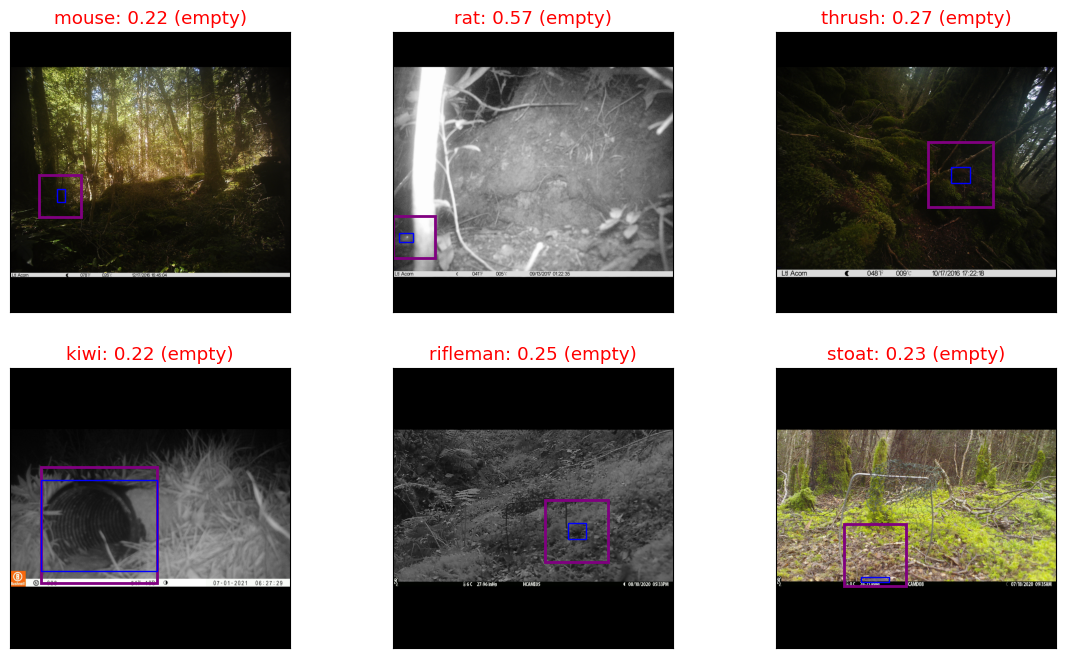

In [75]:
num_ims = max(6, len(mistakes))
if len(mistakes):
    show_inferred_imgs(empties_df[empties_df['Encounter'] != 'empty'], num_ims=6)

In [76]:
empty_count = (empties_df['Encounter'] == 'empty').sum()
n_empties = len(empties_df)
accuracy = empty_count / n_empties
print(f'The accuracy on {n_empties} images was {accuracy:.2f}')

The accuracy on 561 images was 0.93


Let's take a look at the distribution of probability scores that produced this result and compare to the MegaDetector Scores


This needs changing.  It would be more useful to get the maximum of the animal scores, since post processing has already faffed with the empties already.

In [77]:
empties_df['max_all_classes'] = empties_df[all_classes].max(axis=1)
empties_df.iloc[:8,:7].head()

,Date_Time,Encounter_Start,Encounter,Max_Prob,Targets,Prediction,Probability
File_Path,,,,,,,
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Adam_2018_1_Camera1_6__4401F40B-1730-409A-B9C7-2D062BD3E820.JPG,01/01/2011 00:00:23,00:00:23,blackbird,0.288,empty,blackbird,0.288
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Wayne_2016_1_Camera1_4__2679B2F9-5B71-4069-8D46-B15CBD419AF2.JPG,05/01/2011 12:53:46,12:53:46,empty,0.000,empty,empty,0.000
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Graeme_2018_1_Camera1_9__9E65B835-EFFF-4187-B11D-B54B0E198AB4.JPG,27/01/2011 14:10:35,14:10:35,empty,0.000,empty,empty,0.000
/home/olly/Desktop/Alita/Data/Empty_Images/defo/IMG_0006.JPG,16/01/2015 00:57:59,00:57:59,empty,0.000,empty,empty,0.000
/home/olly/Desktop/Alita/Data/Empty_Images/defo/Wayne_2016_2_Camera1_1__68B9653A-1B54-462B-A19C-BC5EDC3D184C.JPG,19/10/2015 15:18:55,15:18:55,empty,0.000,empty,empty,0.000


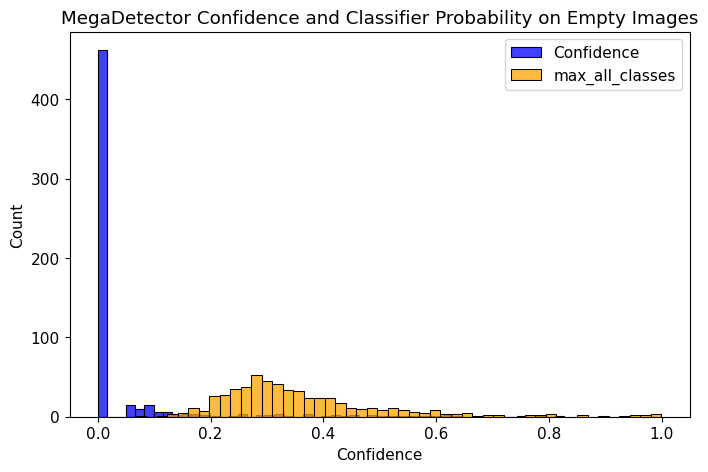

In [78]:
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

plt.figure(figsize=(8, 5))
sns.histplot(data=empties_df, x='Confidence',  bins=50, kde=False, label='Confidence', color='blue')
sns.histplot(data=empties_df, x='max_all_classes',  bins=50, kde=False, label='max_all_classes', color='orange')
plt.title('MegaDetector Confidence and Classifier Probability on Empty Images')
plt.legend()
plt.show()

Now let's combine the empties and the independent dataframe, remove anything with less than 30 samples, and generate some overall metrics for reporting purposes.

In [79]:
filtered_encounter_df = inferred_df.groupby('Targets').filter(lambda x: len(x) >= 30)
print(list(filtered_encounter_df['Targets'].unique()))

['blackbird', 'cat', 'deer', 'dunnock', 'fantail', 'ferret', 'goat', 'hare', 'harrier', 'hedgehog', 'human', 'kea', 'kereru', 'kiwi', 'magpie', 'mouse', 'paradise_duck', 'pheasant', 'pig', 'pipit', 'possum', 'rabbit', 'rat', 'rifleman', 'robin', 'silvereye', 'stoat', 'thrush', 'tomtit', 'wallaby', 'weka']


In [80]:
df_with_empties = pd.concat([filtered_encounter_df.copy(), empties_df.copy()], ignore_index=True)
print(list(df_with_empties['Targets'].unique()))

['blackbird', 'cat', 'deer', 'dunnock', 'fantail', 'ferret', 'goat', 'hare', 'harrier', 'hedgehog', 'human', 'kea', 'kereru', 'kiwi', 'magpie', 'mouse', 'paradise_duck', 'pheasant', 'pig', 'pipit', 'possum', 'rabbit', 'rat', 'rifleman', 'robin', 'silvereye', 'stoat', 'thrush', 'tomtit', 'wallaby', 'weka', 'empty']


In [81]:
print(list(df_with_empties['Encounter'].unique()))

['blackbird', 'empty', 'weka', 'shore_plover', 'mouse', 'robin', 'tomtit', 'dunnock', 'thrush', 'bellbird', 'fantail', 'human', 'finch', 'cat', 'possum', 'kiwi', 'dog', 'wallaby', 'deer', 'hare', 'stoat', 'rifleman', 'ferret', 'goat', 'cow', 'pig', 'chamois', 'rabbit', 'kea', 'harrier', 'hedgehog', 'rat', 'sealion', 'kereru', 'magpie', 'chicken', 'paradise_duck', 'pheasant', 'pipit', 'sheep', 'silvereye', 'weasel', 'pateke']


Let's look at the MD confidence scores, for true empties, vs images with animals.

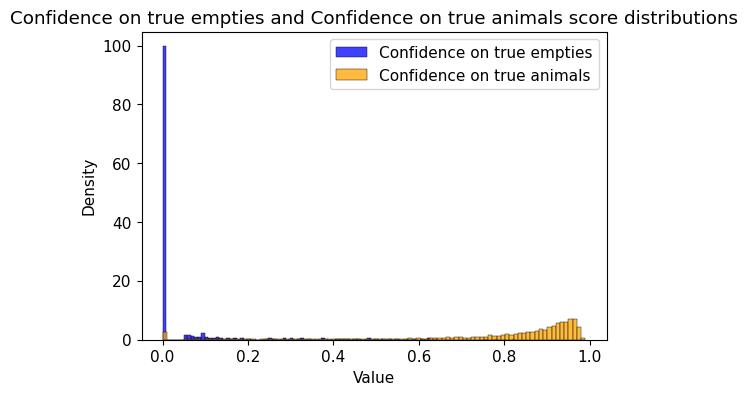

In [82]:
true_empties = df_with_empties[df_with_empties['Targets']=='empty']['Confidence'].values
false_empties = df_with_empties[df_with_empties['Targets']!='empty']['Confidence'].values

plot_two_distributions(true_empties, 
                        false_empties, 
                        label1='Confidence on true empties', 
                        label2='Confidence on true animals', 
                        x_max=None, 
                        y_max=None,
                        bins=100)

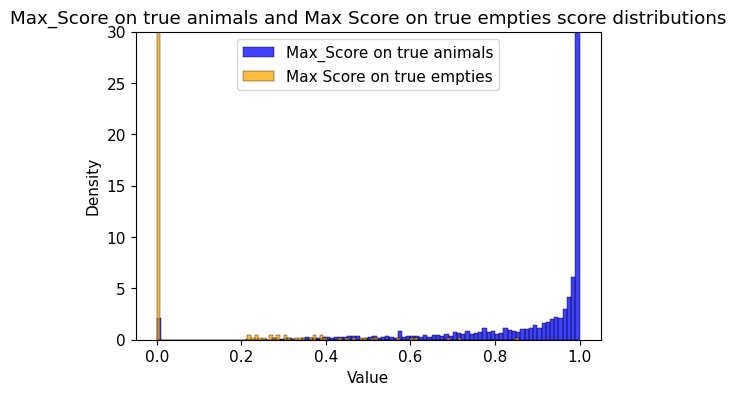

In [83]:
true_empties = df_with_empties[df_with_empties['Targets']=='empty']['Max_Prob'].values
false_empties = df_with_empties[df_with_empties['Targets']!='empty']['Max_Prob'].values

plot_two_distributions( 
                        false_empties, 
                        true_empties,
                        label2='Max Score on true empties', 
                        label1='Max_Score on true animals', 
                        x_max=None, 
                        y_max=30,
                        bins=100)

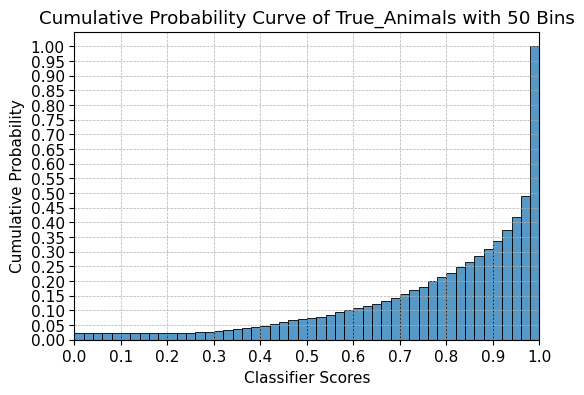

In [84]:
plot_cumulative_probability(pd.DataFrame(false_empties, columns=['True_Animals']), 'True_Animals', x_min=0, x_max=1, bins=50)

From the above, we could consider how high to set the threshold to call something empty, if the maximum score is below this.
For now, it appears that 0.2 is pretty safe.  But this may change in future models.

['bellbird', 'blackbird', 'cat', 'chamois', 'chicken', 'cow', 'deer', 'dog', 'dunnock', 'empty', 'fantail', 'ferret', 'finch', 'goat', 'hare', 'harrier', 'hedgehog', 'human', 'kea', 'kereru', 'kiwi', 'magpie', 'mouse', 'paradise_duck', 'pateke', 'pheasant', 'pig', 'pipit', 'possum', 'rabbit', 'rat', 'rifleman', 'robin', 'sealion', 'sheep', 'shore_plover', 'silvereye', 'stoat', 'thrush', 'tomtit', 'unknown', 'wallaby', 'weasel', 'weka']


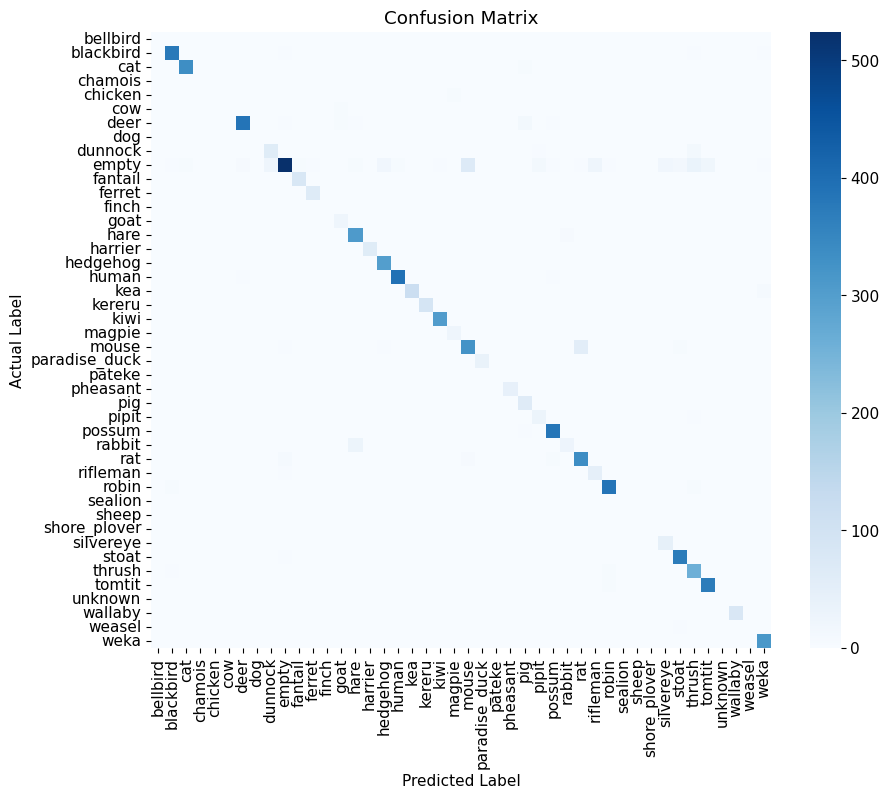

In [85]:
unique_labels_order = sorted(list(set(list(df_with_empties['Targets'].unique()) + list(df_with_empties['Encounter'].unique()) + ['unknown'])))
print(unique_labels_order)
conf_matrix = confusion_matrix(df_with_empties['Encounter'], df_with_empties['Targets'], labels=unique_labels_order)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=False, fmt='d', cmap='Blues',
            xticklabels=unique_labels_order, yticklabels=unique_labels_order)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [86]:
len(df_with_empties)

7218

In [87]:
precision = precision_score(df_with_empties['Targets'], df_with_empties['Encounter'], average=None, labels=unique_labels_order, zero_division=1)
recall = recall_score(df_with_empties['Targets'], df_with_empties['Encounter'],  average=None, labels=unique_labels_order, zero_division=1)

targets = np.array( df_with_empties['Targets'].to_list())
predictions = np.array(df_with_empties['Encounter'].to_list())
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    bal_accuracy = balanced_accuracy_score(targets, predictions)

animals_of_interest = ['possum','empty', 'cat', 'stoat', 'ferret', 'hedgehog', 'mouse', 'rabit', 
                       'hare', 'kiwi', 'kereru', 'goat','pig', 'pipit', 'deer', 'human', 'rat', 
                       'blackbird', 'robin', 'weka', 'harrier', 'paradise_duck']
target_counts = df_with_empties['Targets'].value_counts()

print(Colour.S + f'The balanced accuracy score on this dataset is {bal_accuracy: .2f}' + Colour.E + "\n")
for label, prec, rec in zip(unique_labels_order, precision, recall):
    if label in animals_of_interest:
        count = target_counts.get(label, 0)  # Get the count for the current label
        print(f'{label}: Precision={prec:.2f}, Recall={rec:.2f}, Targets={count}')

The balanced accuracy score on this dataset is  0.88

blackbird: Precision=0.97, Recall=0.94, Targets=400
cat: Precision=0.97, Recall=0.97, Targets=347
deer: Precision=0.93, Recall=0.96, Targets=400
empty: Precision=0.64, Recall=0.93, Targets=561
ferret: Precision=1.00, Recall=0.96, Targets=70
goat: Precision=0.92, Recall=0.59, Targets=41
hare: Precision=0.97, Recall=0.88, Targets=351
harrier: Precision=1.00, Recall=1.00, Targets=62
hedgehog: Precision=1.00, Recall=0.93, Targets=323
human: Precision=0.97, Recall=0.98, Targets=400
kereru: Precision=1.00, Recall=0.99, Targets=93
kiwi: Precision=0.98, Recall=0.98, Targets=310
mouse: Precision=0.81, Recall=0.81, Targets=400
paradise_duck: Precision=1.00, Recall=0.97, Targets=39
pig: Precision=0.98, Recall=0.73, Targets=88
pipit: Precision=0.88, Recall=0.64, Targets=47
possum: Precision=0.98, Recall=0.95, Targets=400
rat: Precision=0.94, Recall=0.84, Targets=400
robin: Precision=0.97, Recall=0.96, Targets=400
stoat: Precision=0.98, Recall=0

With md_empty limit at 0.2, classify_empty_limit 0.2, total score = 0.881,  empty Precision 0.64, Recall 0.94. 

In [88]:
df_with_empties.head()

,Date_Time,Encounter_Start,Encounter,Max_Prob,Targets,Prediction,Probability,...,weasel,weka,white_faced_heron,wrybill,yellow_eyed_penguin,yellowhammer,max_all_classes
0,01/01/2018 00:00:00,00:00:00,blackbird,0.992,blackbird,blackbird,0.977,...,0.0,0.000,0.0,0.0,0.0,0.0,NaN
1,01/01/2018 00:00:00,00:00:00,blackbird,0.992,blackbird,blackbird,0.992,...,0.0,0.000,0.0,0.0,0.0,0.0,NaN
2,01/01/2018 00:00:00,00:00:00,blackbird,0.992,blackbird,blackbird,0.907,...,0.0,0.000,0.0,0.0,0.0,0.0,NaN
3,01/01/2018 00:00:00,00:00:00,blackbird,0.992,blackbird,blackbird,0.772,...,0.0,0.001,0.0,0.0,0.0,0.0,NaN
4,01/01/2018 00:00:00,00:00:00,blackbird,0.992,blackbird,blackbird,0.758,...,0.0,0.008,0.0,0.0,0.0,0.0,NaN


In [89]:
col_headers = ['Encounter',	'Confidence', 'Max_Prob', 'Targets', 'Prediction']
animals = list({'mouse', 'hedgehog', 'cat', 'deer', 'blackbird', 'tomtit', 'dunnock'} & set(df_with_empties.columns.to_list()))
df_with_empties[col_headers + animals][(df_with_empties['Encounter']=='empty') & (df_with_empties['Targets']!='empty')].head(10)

,Encounter,Confidence,Max_Prob,Targets,Prediction,dunnock,mouse,deer,hedgehog,blackbird,tomtit,cat
69,empty,0.082,0.401,blackbird,empty,0.005,0.004,0.004,0.000,0.878,0.005,0.001
84,empty,0.060,0.000,blackbird,empty,0.041,0.106,0.090,0.008,0.139,0.188,0.103
93,empty,0.000,0.000,blackbird,empty,0.009,0.065,0.071,0.001,0.021,0.019,0.085
490,empty,0.000,0.989,cat,empty,0.030,0.185,0.191,0.018,0.046,0.045,0.224
560,empty,0.000,0.000,cat,empty,0.001,0.140,0.023,0.014,0.023,0.014,0.414
561,empty,0.000,0.000,cat,empty,0.001,0.129,0.019,0.011,0.029,0.015,0.496
562,empty,0.000,0.000,cat,empty,0.000,0.035,0.007,0.004,0.008,0.006,0.769
565,empty,0.000,0.963,cat,empty,0.002,0.101,0.047,0.008,0.040,0.018,0.397
568,empty,0.087,0.000,cat,empty,0.000,0.011,0.011,0.009,0.001,0.005,0.134
754,empty,0.108,0.975,deer,empty,0.000,0.004,0.908,0.000,0.002,0.007,0.004


In [90]:
df_with_empties[col_headers + animals][df_with_empties['Targets']=='empty'].head()

,Encounter,Confidence,Max_Prob,Targets,Prediction,dunnock,mouse,deer,hedgehog,blackbird,tomtit,cat
6657,blackbird,0.520,0.288,empty,blackbird,0.139,0.132,0.148,0.017,0.288,0.144,0.078
6658,empty,0.000,0.000,empty,empty,0.038,0.031,0.364,0.001,0.065,0.053,0.064
6659,empty,0.000,0.000,empty,empty,0.040,0.049,0.087,0.000,0.027,0.009,0.037
6660,empty,0.000,0.000,empty,empty,0.000,0.010,0.150,0.064,0.000,0.000,0.040
6661,empty,0.056,0.000,empty,empty,0.000,0.033,0.009,0.000,0.001,0.000,0.004


## Log the overall performance and compare with previous runs

In [91]:
column_headers = ['Experiment', 'Run_ID', 'Date-Hour', 'Num_Val_Species', 'Num_Val_Imgs', 
                  'Val_Acc', 'Val_Bal_Acc', 'Val_mAP', 'Val_F1', 
                  'Num_Test_Locn_Species', 'Num_Test_Imgs', 'Test_Acc', 'Test_Bal_Acc',
                  'Test_mAP', 'Test_F1', 'Bal_Acc_W_Empt'] + important_animals + ['Imgs_per_sec']
print(column_headers)
if paths.performance_log_pth.exists():
    df = pd.read_csv(paths.performance_log_pth)
else:
    df = pd.DataFrame(columns=column_headers)

['Experiment', 'Run_ID', 'Date-Hour', 'Num_Val_Species', 'Num_Val_Imgs', 'Val_Acc', 'Val_Bal_Acc', 'Val_mAP', 'Val_F1', 'Num_Test_Locn_Species', 'Num_Test_Imgs', 'Test_Acc', 'Test_Bal_Acc', 'Test_mAP', 'Test_F1', 'Bal_Acc_W_Empt', 'cat', 'mouse', 'possum', 'rat', 'stoat', 'Imgs_per_sec']


In [92]:
bal_accuracy

0.8810373226010889

In [93]:
metrics_list_1 = [overall_acc_1, balanced_acc_1, map_1, f1_1]
metrics_list_2 = [overall_acc_2, balanced_acc_2, map_2, f1_2]
now = datetime.now().strftime('%y_%m_%d_%H')
row_list = [train_cfg.EXPERIMENT_NAME, train_cfg.RUN_ID, now, num_val_species, num_val_images] + metrics_list_1 + \
            [num_independent_species, num_independent_images] + metrics_list_2 + [bal_accuracy] + important_animal_scores + [speed]
new_row_dict = dict(zip(column_headers, row_list))
for key, value in new_row_dict.items():
    if isinstance(value, (int, float)):
        new_row_dict[key] = round(value, 3)
df.loc[len(df)] = new_row_dict
print(Colour.S + 'Metrics from the test dataset' + Colour.E)
df.iloc[-8:,:10]

Metrics from the test dataset


,Experiment,Run_ID,Date-Hour,Num_Val_Species,Num_Val_Imgs,Val_Acc,Val_Bal_Acc,Val_mAP,Val_F1,Num_Test_Locn_Species
22,Exp_46,Run_21,25_03_20_17,61,38016,0.93,0.863,0.923,0.877,28
23,Exp_46,Run_21,25_03_20_17,61,38016,0.93,0.863,0.923,0.877,28
24,Exp_46,Run_21,25_03_20_17,61,38016,0.93,0.863,0.923,0.877,28
25,Exp_46,Run_21,25_03_20_17,61,38016,0.93,0.863,0.923,0.877,28
26,Exp_46,Run_21,25_03_20_17,61,38016,0.93,0.863,0.923,0.877,28
27,Exp_46,Run_21,25_03_20_18,61,38016,0.93,0.863,0.923,0.877,28
28,Exp_46,Run_21,25_03_20_18,61,38016,0.93,0.863,0.923,0.877,28
29,Exp_46,Run_21,25_03_20_18,61,38016,0.93,0.863,0.923,0.877,28


In [94]:
print(Colour.S + 'Metrics from the independent monitoring dataset' + Colour.E)
df.iloc[-8:,10:]

Metrics from the independent monitoring dataset


,Num_Test_Imgs,Test_Acc,Test_Bal_Acc,Test_mAP,Test_F1,Bal_Acc_W_Empt,cat,mouse,possum,rat,stoat,Imgs_per_sec
22,6553,0.922,0.886,0.941,0.899,0.881,0.993,0.878,0.991,0.95,0.989,47.232
23,6553,0.922,0.886,0.941,0.899,0.877,0.993,0.878,0.991,0.95,0.989,47.804
24,6553,0.922,0.886,0.941,0.899,0.879,0.993,0.878,0.991,0.95,0.989,49.638
25,6553,0.922,0.886,0.941,0.899,0.881,0.993,0.878,0.991,0.95,0.989,48.228
26,6553,0.922,0.886,0.941,0.899,0.880,0.993,0.878,0.991,0.95,0.989,47.793
27,6553,0.922,0.886,0.941,0.899,0.881,0.993,0.878,0.991,0.95,0.989,44.361
28,6553,0.922,0.886,0.941,0.899,0.862,0.993,0.878,0.991,0.95,0.989,45.838
29,6553,0.922,0.886,0.941,0.899,0.881,0.993,0.878,0.991,0.95,0.989,43.851


In [95]:
df.to_csv(paths.performance_log_pth, index = False)
print(Colour.S +'Monitoring file saved to: ' + Colour.E, paths.performance_log_pth)

Monitoring file saved to:  /home/olly/Desktop/Alita/Python/Setup/Performance_Monitor.csv
